# Create tables for each tract and block group with all variables
In section 5.1 need to report specific numbers for each indicator. Selected numbers will be reported in the text.

## Description of Program
- program:    tu3svi4_6dv1_Phase2Text
- task:       Set up table for published paper
- Version:   
- 2025-04-25: Generate numbers for text 
- 2025-11-05: Look at equal weighting and aggregation for HRRC and SVInsight
- project:    DOE Southeast Texas Urban Field Lab SVI Paper - round 4 of analysis 
- funding:	  DOE
- author:    Nathanael Rosenheim
- GRA:        Lidia Mezei

## Control Python
Add install and add packages.

In [1]:
import pandas as pd     # For obtaining and cleaning tabular data
import geopandas as gpd # For obtaining and cleaning spatial data
import numpy as np      # For working with arrays
import geopandas as gpd # For working with spatial data
import matplotlib.pyplot as plt # For plotting
import os # For saving to path

In [2]:
import sys
print("Python Version     ", sys.version)
print("geopandas version: ", gpd.__version__)

Python Version      3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50) [MSC v.1916 64 bit (AMD64)]
geopandas version:  0.14.2


## Set Provenance 

In [3]:
# Get information on current working directory (getcwd)
os.getcwd()

'c:\\Users\\nathanael99\\Box\\SETx-UIFL_Team-folder\\Theme_3_eq\\Text\\SVI_Analysis_Paper\\WorkNPR'

In [4]:
# Store Program Name for SVInsightut files to have the same name and saved in the same directory
programname = "tu3svi4_6dv2_Phase2Text_2025-11-05"
# Make directory to save output
if not os.path.exists(programname):
   os.mkdir(programname)

# Obtain Data
Obtain data from about each variable in SVI data.

In [5]:
# read in original Version 1 data
sourceprogram = "tu3svi4_2av2_SVIoptions_2025-04-16"
sourcefile = sourceprogram+"/"+sourceprogram+"_all_vars_tract2020.csv"
# read in file and set ids as strings
Tract_df = pd.read_csv(sourcefile, dtype={'TRACT2020':str}, low_memory=False)

sourcefile = sourceprogram+"/"+sourceprogram+"_all_vars_bg2020.csv"
BG_df = pd.read_csv(sourcefile, dtype={'TRACT2020':str, 'BG2020': str}, low_memory=False)

In [6]:
Tract_df.head()

,TRACT2020,ALAND,AWATER,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,...,H202081011,H202090012,H202090093,H202091012,H202091093,H202092021,SETX,FIPSCNTY,airsite_tract,airsite_name
0,48189950200,6306913,0,0.26355,0.29075,0.05352,-15052.0,-0.00000,-59500.0,537.0,...,0.36285,97.0,0.844,4.0,4.0,1.0,0.0,48189.0,0.0,NaN
1,48219950400,12691656,5302,0.21368,0.40714,0.10448,-16492.0,-0.00000,-43800.0,637.0,...,0.29107,93.6,0.796,4.0,4.0,1.0,0.0,48219.0,0.0,NaN
2,48219950300,12186639,0,0.23184,0.27081,0.05693,-26892.0,-0.02171,-98500.0,860.0,...,0.12183,74.7,0.643,3.0,3.0,1.0,0.0,48219.0,0.0,NaN
3,48219950100,214157569,0,0.13342,0.36347,0.08676,-20890.0,-0.01476,-60200.0,616.0,...,0.28967,80.9,0.686,4.0,4.0,1.0,0.0,48219.0,0.0,NaN
4,48219950600,358638163,0,0.11713,0.31648,0.01074,-34403.0,-0.09363,-97100.0,814.0,...,0.18914,40.9,0.445,2.0,2.0,1.0,0.0,48219.0,0.0,NaN


In [7]:
# read in table 1 details
sourceprogram = "tu3svi4_6av1_Table1_2025-04-12"
sourcefile = sourceprogram+"/"+sourceprogram+".csv"
table1_df = pd.read_csv(sourcefile)
table1_df.head()

,year,General Category,gencatcode,comcatcode,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname UTP
0,2018,Geocode,100,10,TRACT2010,NaN,NaN,NaN,C201810010,H201810010,U201810010
1,2020,Geocode,100,10,TRACT2020,NaN,NaN,NaN,C202010010,H202010010,U202010010
2,2018,Geocode,100,11,BG2010,NaN,NaN,NaN,NaN,H201810011,U201810011
3,2020,Geocode,100,11,BG2020,NaN,NaN,NaN,NaN,H202010011,U202010011
4,2018,Denominator,100,20,Population,S0601,unknown,NaN,C201810020,H201810020,NaN


In [8]:
## Read in CDC SVI data 
sourcefolder = "../SourceData/www_atsdr_cdc_gov_placeandhealth_svi"
sourcefile = "CDC_2020_TX_Tract_2023-11-09.csv"
file_path = os.path.join(sourcefolder, sourcefile)
# read in file and make FIPS a string
cdcsvi_tract_df = pd.read_csv(file_path, dtype={'FIPS': str})
cdcsvi_tract_df.head()

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,48,Texas,TX,48001,Anderson,48001950100,"Census Tract 9501, Anderson County, Texas",186.605650,4958,736,...,1.0,1.4,0.4,0.5,0.0,0.9,8.0,4.7,0.0,0.1
1,48,Texas,TX,48001,Anderson,48001950401,"Census Tract 9504.01, Anderson County, Texas",6.374261,4867,838,...,0.2,0.3,0.2,0.4,0.0,0.9,2.2,1.5,0.3,0.4
2,48,Texas,TX,48001,Anderson,48001950402,"Census Tract 9504.02, Anderson County, Texas",27.465086,7335,352,...,0.1,0.2,0.1,0.2,0.1,0.2,1.1,0.8,0.0,0.6
3,48,Texas,TX,48001,Anderson,48001950500,"Census Tract 9505, Anderson County, Texas",8.931332,4397,575,...,0.0,1.0,0.0,1.0,0.0,1.0,1.8,1.5,0.0,1.0
4,48,Texas,TX,48001,Anderson,48001950600,"Census Tract 9506, Anderson County, Texas",7.974505,4704,915,...,0.0,1.0,0.0,1.0,0.0,1.0,1.5,2.3,0.0,1.0


In [9]:
## Read in CDC SVI data 
sourcefolder = "../SourceData/www_atsdr_cdc_gov_placeandhealth_svi"
sourcefile = "CDC_2020_US_Tract_2023-11-09.csv"
file_path = os.path.join(sourcefolder, sourcefile)
# read in file and make FIPS a string
cdcsvi_tract_df_US = pd.read_csv(file_path, dtype={'FIPS': str})
cdcsvi_tract_df_US.head()

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,Alabama,AL,1001,Autauga,01001020100,"Census Tract 201, Autauga County, Alabama",3.793570,1941,390,...,2.1,2.7,0.0,1.8,0.0,1.8,6.6,5.1,0.0,1.8
1,1,Alabama,AL,1001,Autauga,01001020200,"Census Tract 202, Autauga County, Alabama",1.282174,1757,310,...,0.0,2.0,0.0,2.0,0.0,2.0,2.6,3.0,0.8,1.1
2,1,Alabama,AL,1001,Autauga,01001020300,"Census Tract 203, Autauga County, Alabama",2.065364,3694,570,...,1.2,1.1,0.0,0.9,0.0,0.9,1.8,2.3,0.0,0.9
3,1,Alabama,AL,1001,Autauga,01001020400,"Census Tract 204, Autauga County, Alabama",2.464984,3539,500,...,0.5,0.6,0.3,0.5,0.0,1.0,2.9,2.8,0.0,1.0
4,1,Alabama,AL,1001,Autauga,01001020501,"Census Tract 205.01, Autauga County, Alabama",2.395243,4306,662,...,1.9,2.0,0.0,0.8,0.0,0.8,0.3,0.6,0.0,0.8


In [10]:
# rename newvarname UTP = newvarname SVInsight
table1_df.rename(columns={'newvarname UTP': 'newvarname SVInsight'}, inplace=True)
table1_df.head()

,year,General Category,gencatcode,comcatcode,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname SVInsight
0,2018,Geocode,100,10,TRACT2010,NaN,NaN,NaN,C201810010,H201810010,U201810010
1,2020,Geocode,100,10,TRACT2020,NaN,NaN,NaN,C202010010,H202010010,U202010010
2,2018,Geocode,100,11,BG2010,NaN,NaN,NaN,NaN,H201810011,U201810011
3,2020,Geocode,100,11,BG2020,NaN,NaN,NaN,NaN,H202010011,U202010011
4,2018,Denominator,100,20,Population,S0601,unknown,NaN,C201810020,H201810020,NaN


## Calculate Percentile Rank for Each Variable

In [11]:
Tract_df[['ALAND','AWATER','C202010020','C202020010']].describe().T

,count,mean,std,min,25%,50%,75%,max
ALAND,6896.0,9.812654e+07,4.753323e+08,0.0,1983338.500,4030966.500,1.812604e+07,1.599487e+10
AWATER,6896.0,2.752226e+06,2.523451e+07,0.0,0.000,7687.000,1.958068e+05,8.663851e+08
C202010020,6884.0,4.159710e+03,1.876296e+03,0.0,2811.750,3939.000,5.193000e+03,1.970400e+04
C202020010,6884.0,2.490825e-01,1.684516e-01,0.0,0.112,0.221,3.590000e-01,1.000000e+00


In [12]:
## Loop over Tract_df and BG_df to add new variables

from sklearn.preprocessing import MinMaxScaler
import scipy.stats as stats

# Initialize MinMaxScaler
scaler = MinMaxScaler()


def add_percentile_rank_minmax(df, geoid, popvar):
    df = df.copy()
    column_list = df.columns
    # remove TRACT2020 from column list
    column_list = column_list[column_list != geoid]
    # remove SETX	FIPSCNTY	airsite_tract	airsite_name
    remove_list = ['FIPSCNTY', 'airsite_tract','airsite_bg', 'airsite_name']
    column_list = column_list[~column_list.isin(remove_list)]
    for column in column_list:
        # how many values non missing values are in the column
        condition1 = df[column].isna()
        condition2 = df[popvar] > 0 # total population > 0
        condition = ~condition1 & condition2
        df_v2 = df[condition][[geoid,column]]
        length = len(df_v2)
        #print(f"Number of rows in Tract_df with {column} non missing values: ", length)
        # invert rankings for 3 SVInsight variables
        # invert_vars = ['U202020031','U202020033','U202020040']
        # UT variables already inverted
        # Calculate percentile rank and add as a new column
        # min means that if there are ties then the min rank is assigned to all tied values
        df_v2[f'{column}rank'] = stats.rankdata(df_v2[column], method='min', nan_policy='omit')
        df_v2[f'{column}pr'] = df_v2[f'{column}rank'] / length
        # round to the fourth decimal place
        df_v2[f'{column}pr'] = df_v2[f'{column}pr'].round(4)
        # replace pr with 0 if column is 0
        df_v2.loc[df_v2[column] == 0, f'{column}pr'] = 0.0

        # Scale data using MinMaxScaler and add as a new column
        df_v2[f'{column}mm'] = scaler.fit_transform(df_v2[[column]])
        # round to the fourth decimal place
        df_v2[f'{column}mm'] = df_v2[f'{column}mm'].round(4)
        # Add the new columns to the original dataframe
        df = df.merge(df_v2[[geoid, f'{column}rank', f'{column}pr', f'{column}mm']], on=geoid, how='left')


        # select southeast texas and add rank 
        condition1 = df['SETX'] == 1
        df_v3 = df[condition1][[geoid,column]]
        df_v3[f'{column}SETXrank'] = stats.rankdata(df_v3[column], method='min', nan_policy='omit')
        # Add the new columns to the original dataframe
        df = df.merge(df_v3[[geoid, f'{column}SETXrank']], on=geoid, how='left')
    
    return df

# Add percentile rank and min-max scaled values to Tract_df
Tract_df_v2 = add_percentile_rank_minmax(Tract_df, 'TRACT2020', 'C202010020')
BG_df_v2 = add_percentile_rank_minmax(BG_df, "BG2020", 'H202010020')
Tract_df_v2.head()

,TRACT2020,ALAND,AWATER,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,...,H202091093mm,H202091093SETXrank,H202092021rank,H202092021pr,H202092021mm,H202092021SETXrank,SETXrank,SETXpr,SETXmm,SETXSETXrank
0,48189950200,6306913,0,0.26355,0.29075,0.05352,-15052.0,-0.00000,-59500.0,537.0,...,1.0000,NaN,1.0,0.0001,0.0,NaN,1.0,0.0,0.0,NaN
1,48219950400,12691656,5302,0.21368,0.40714,0.10448,-16492.0,-0.00000,-43800.0,637.0,...,1.0000,NaN,1.0,0.0001,0.0,NaN,1.0,0.0,0.0,NaN
2,48219950300,12186639,0,0.23184,0.27081,0.05693,-26892.0,-0.02171,-98500.0,860.0,...,0.6667,NaN,1.0,0.0001,0.0,NaN,1.0,0.0,0.0,NaN
3,48219950100,214157569,0,0.13342,0.36347,0.08676,-20890.0,-0.01476,-60200.0,616.0,...,1.0000,NaN,1.0,0.0001,0.0,NaN,1.0,0.0,0.0,NaN
4,48219950600,358638163,0,0.11713,0.31648,0.01074,-34403.0,-0.09363,-97100.0,814.0,...,0.3333,NaN,1.0,0.0001,0.0,NaN,1.0,0.0,0.0,NaN


In [13]:
BG_df_v2.head()

,BG2020,ALAND,AWATER,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,...,H202092021mm,H202092021SETXrank,SETXrank,SETXpr,SETXmm,SETXSETXrank,TRACT2020rank,TRACT2020pr,TRACT2020mm,TRACT2020SETXrank
0,481539506003,9238641,0,0.12273,0.59882,0.02113,-41060.0,-0.02360,-73300.0,3501.0,...,0.0,NaN,1.0,0.0,0.0,NaN,6678.0,0.3610,0.3004,NaN
1,481539506005,1070676551,101332,0.33274,0.08228,0.00000,-22793.0,-0.06962,-163500.0,663.0,...,0.0,NaN,1.0,0.0,0.0,NaN,6678.0,0.3610,0.3004,NaN
2,481610004001,12766486,8204,0.30405,0.36973,0.05444,-17938.0,-0.00000,-78900.0,727.0,...,0.0,NaN,1.0,0.0,0.0,NaN,7065.0,0.3820,0.3143,NaN
3,481610006001,153883256,544987,0.00000,0.50709,0.00000,-27873.0,-0.14894,-153900.0,661.0,...,0.0,NaN,1.0,0.0,0.0,NaN,7067.0,0.3821,0.3143,NaN
4,481759602001,391287006,1789495,0.18392,0.56607,0.01743,-32928.0,-0.07495,-157900.0,393.0,...,0.0,NaN,1.0,0.0,0.0,NaN,7410.0,0.4006,0.3439,NaN


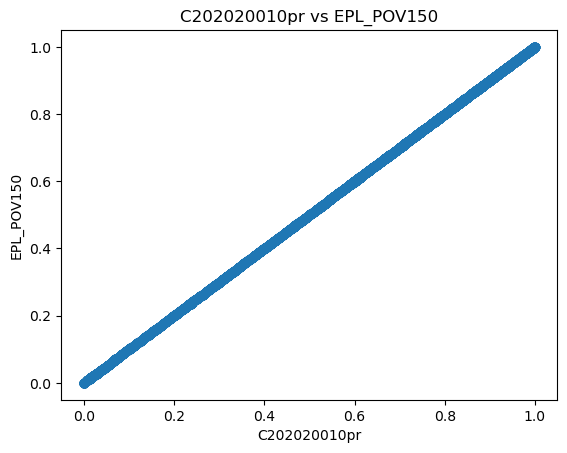

In [14]:
# compare percentile rank C202020010pr with EPL_POV150
# merge df with SVI data
df_compare = Tract_df_v2.merge(cdcsvi_tract_df[['FIPS','E_TOTPOP','E_POV150','EP_POV150','EPL_POV150']], left_on='TRACT2020', right_on='FIPS', how='left')
# replace -999 with NaN
df_compare['EPL_POV150'] = df_compare['EPL_POV150'].replace(-999, np.nan)
# scatter plot
plt.scatter(df_compare['C202020010pr'], df_compare['EPL_POV150'])
plt.xlabel('C202020010pr')
plt.ylabel('EPL_POV150')
plt.title('C202020010pr vs EPL_POV150')
plt.show()

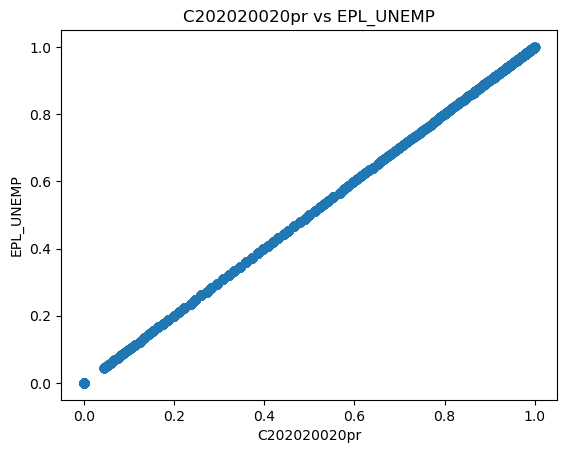

In [15]:
# compare percentile rank C202020010pr with compare variable
comparevar = 'UNEMP'
comparevar2 = 'C202020020'
# merge df with SVI data
df_compare = Tract_df_v2.merge(cdcsvi_tract_df[['FIPS','E_TOTPOP',f'E_{comparevar}',f'EP_{comparevar}',f'EPL_{comparevar}']], left_on='TRACT2020', right_on='FIPS', how='left')
# replace -999 with NaN
df_compare[f'EPL_{comparevar}'] = df_compare[f'EPL_{comparevar}'].replace(-999, np.nan)
# scatter plot
plt.scatter(df_compare[f'{comparevar2}pr'], df_compare[f'EPL_{comparevar}'])
plt.xlabel(f'{comparevar2}pr')
plt.ylabel(f'EPL_{comparevar}')
plt.title(f'{comparevar2}pr vs EPL_{comparevar}')
plt.show()

In [16]:
# what is the correlation between C202020010pr and EPL_POV150
df_compare[[f'{comparevar2}pr',f'EPL_{comparevar}']].corr().iloc[0,1]

0.999999985803168

In [17]:
df_compare[['TRACT2020','E_TOTPOP','C202010020',f'{comparevar2}',f'{comparevar2}pr',f'E_{comparevar}',f'EP_{comparevar}',f'EPL_{comparevar}']].head()

,TRACT2020,E_TOTPOP,C202010020,C202020020,C202020020pr,E_UNEMP,EP_UNEMP,EPL_UNEMP
0,48189950200,3998.0,3998.0,0.054,0.5858,95.0,5.4,0.5858
1,48219950400,4472.0,4472.0,0.104,0.8883,189.0,10.4,0.8883
2,48219950300,4255.0,4255.0,0.057,0.6146,124.0,5.7,0.6146
3,48219950100,1495.0,1495.0,0.087,0.8297,57.0,8.7,0.8297
4,48219950600,1596.0,1596.0,0.011,0.0974,8.0,1.1,0.0972


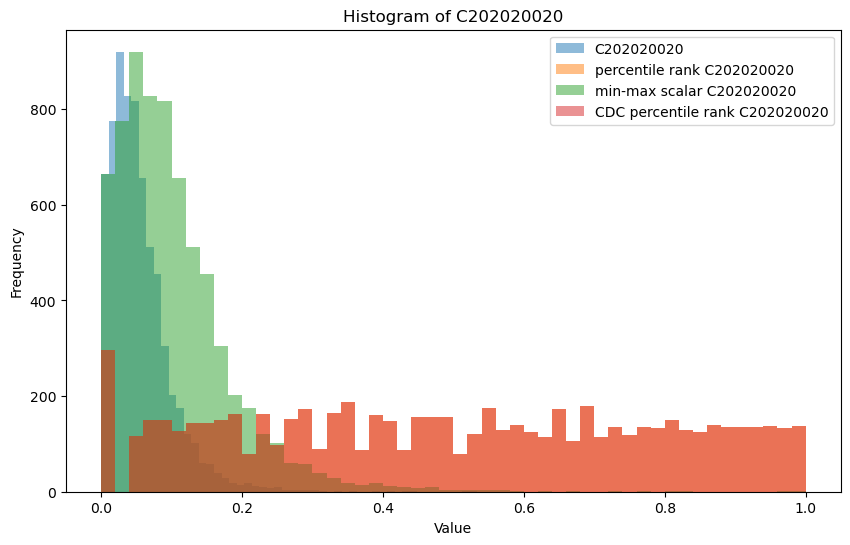

In [18]:

# make a histogram of variable
variable = comparevar2
# how many values non missing values are in the column
condition1 = df_compare[variable].isna()
condition2 = df_compare['C202010020'] > 0 # total population > 0
condition = ~condition1 & condition2
df_plot = df_compare[condition].copy()
plt.figure(figsize=(10, 6))
plt.hist(df_plot[variable], bins=50, alpha=0.5, label=variable)
plt.hist(df_plot[f"{variable}pr"], bins=50, alpha=0.5, label="percentile rank "+variable)
plt.hist(df_plot[f"{variable}mm"], bins=50, alpha=0.5, label="min-max scalar "+variable)  
plt.hist(df_plot[f'EPL_{comparevar}'], bins=50, alpha=0.5, label="CDC percentile rank "+variable) 
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title(f'Histogram of {variable}')
plt.legend()
plt.show()


#### Understanding Percentile rank vs Min-Max Scale
it looks like the CDC is using percentile rank where population is greater than 0 and where the indicator is not missing. Additionally in the case of ties the CDC seems to take the minimum value. For example, if there are 20 tracts with 0 poverty then all of them are ranked as 0.

The min-max scaling appears to keep the distribution of the underlying data. Low values of poverty will have low min-max values. This probably will work itself out in the factor analysis were different factors will have different loadings. But it is interesting to see the difference. 

### Replicate CDC SVI Score based on calculated rankings
Working on addition to Section 5.2 of paper (revise and resubmit version). Goal is to check how using CDC weighting and aggregation change the SVI scores for the HRRC and SVInsight.

First - check to make sure new percentile ranks calculated earlier replicate CDC SVI

Second - Apply method to HRRC and SVInsight percentile ranks

In [19]:
# look at CDC percentile ranks
# collect variables that start with EPL
epl_vars = [col for col in cdcsvi_tract_df.columns if col.startswith('EPL_')]
epl_vars

['EPL_POV150',
 'EPL_UNEMP',
 'EPL_HBURD',
 'EPL_NOHSDP',
 'EPL_UNINSUR',
 'EPL_AGE65',
 'EPL_AGE17',
 'EPL_DISABL',
 'EPL_SNGPNT',
 'EPL_LIMENG',
 'EPL_MINRTY',
 'EPL_MUNIT',
 'EPL_MOBILE',
 'EPL_CROWD',
 'EPL_NOVEH',
 'EPL_GROUPQ']

In [20]:
# count epl_vars
len(epl_vars)

16

In [21]:
# collect variables that start with C20202 or C20203 or C20204 or C20205 or C20206 or C20207 or C20208 and end with pr
pr_vars = [col for col in Tract_df_v2.columns if (col.startswith('C20202') or 
                                                  col.startswith('C20203') or 
                                                  col.startswith('C20204') or 
                                                  col.startswith('C20205') or 
                                                  col.startswith('C20206') or 
                                                  col.startswith('C20207') or 
                                                  col.startswith('C20208')) and 
                                                  col.endswith('pr')]
pr_vars

['C202020010pr',
 'C202020020pr',
 'C202020031pr',
 'C202020050pr',
 'C202021010pr',
 'C202030010pr',
 'C202033010pr',
 'C202033020pr',
 'C202060010pr',
 'C202062010pr',
 'C202070010pr',
 'C202070020pr',
 'C202070050pr',
 'C202070055pr',
 'C202072010pr',
 'C202081010pr']

In [22]:
# count pr_vars
len(pr_vars)

16

In [23]:
# create new variable that sums the pr variables
# First, create sum but set to NaN if any pr_vars are missing (following CDC methodology)
Tract_df_v2['CDC_pr_sum'] = Tract_df_v2[pr_vars].sum(axis=1)

# Replace CDC_pr_sum with missing if any of the pr_vars are missing
# Check if any variables are missing for each row
missing_any = Tract_df_v2[pr_vars].isna().any(axis=1)
Tract_df_v2.loc[missing_any, 'CDC_pr_sum'] = np.nan

print(f"Total tracts: {len(Tract_df_v2):,}")
print(f"Tracts with missing CDC_pr_sum: {Tract_df_v2['CDC_pr_sum'].isna().sum():,}")
print(f"Tracts with complete CDC_pr_sum: {Tract_df_v2['CDC_pr_sum'].notna().sum():,}")

# describe CDC_pr_sum
Tract_df_v2['CDC_pr_sum'].describe()

Total tracts: 6,896
Tracts with missing CDC_pr_sum: 68
Tracts with complete CDC_pr_sum: 6,828


count    6828.000000
mean        7.621013
std         2.448539
min         0.912300
25%         5.750200
50%         7.620900
75%         9.575450
max        14.283200
Name: CDC_pr_sum, dtype: float64

In [24]:
# describe the SPL Themes variable in the CDC data (replace -999 with NaN first)
cdcsvi_tract_df['SPL_THEMES_v2'] = cdcsvi_tract_df['SPL_THEMES'].replace(-999, np.nan)
cdcsvi_tract_df['SPL_THEMES_v2'].describe()

count    6828.000000
mean        7.620058
std         2.448771
min         0.911700
25%         5.749200
50%         7.619900
75%         9.574650
max        14.282700
Name: SPL_THEMES_v2, dtype: float64

In [25]:
Tract_df_v2['TRACT2020'].describe()

count            6896
unique           6896
top       48189950200
freq                1
Name: TRACT2020, dtype: object

In [26]:
cdcsvi_tract_df['FIPS'].describe()

count            6884
unique           6884
top       48001950100
freq                1
Name: FIPS, dtype: object

In [27]:
# merge CDC SPL_THEMES_v2 to Tract_df_v2
Tract_df_v3 = Tract_df_v2[['TRACT2020']+pr_vars+['CDC_pr_sum']].merge(
                                cdcsvi_tract_df[['FIPS']+epl_vars+['SPL_THEMES','SPL_THEMES_v2','RPL_THEMES']], 
                                left_on='TRACT2020', 
                                right_on='FIPS', 
                                how='left')
Tract_df_v3.head(1).T

,0
TRACT2020,48189950200
C202020010pr,0.7668
C202020020pr,0.5858
C202020031pr,0.2054
C202020050pr,0.7666
C202021010pr,0.92
C202030010pr,0.318
C202033010pr,0.992
C202033020pr,0.9216
C202060010pr,0.7989


In [28]:
# Create data dictionary for SVI variables
data_dict_data = [
    ['C202020010pr', 'Below 150% Poverty', 'EPL_POV150'],
    ['C202020020pr', 'Unemployed', 'EPL_UNEMP'],
    ['C202020031pr', 'Housing Cost Burden', 'EPL_HBURD'],
    ['C202021010pr', 'No High School Diploma', 'EPL_NOHSDP'],
    ['C202020050pr', 'No Health Insurance', 'EPL_UNINSUR'],
    ['C202030010pr', 'Aged 65 or Older', 'EPL_AGE65'],
    ['C202033010pr', 'Single-Parent Households', 'EPL_SNGPNT'],
    ['C202033020pr', 'Aged 17 or Younger', 'EPL_AGE17'],
    ['C202062010pr', 'English Language Proficiency', 'EPL_LIMENG'],
    ['C202081010pr', 'Civilian With a Disability', 'EPL_DISABL'],
    ['C202060010pr', 'Minority', 'EPL_MINRTY'],
    ['C202070010pr', 'Mobile Homes', 'EPL_MOBILE'],
    ['C202070020pr', 'Group Quarters', 'EPL_GROUPQ'],
    ['C202070050pr', 'Multi-Unit Structures', 'EPL_MUNIT'],
    ['C202070055pr', 'Crowding', 'EPL_CROWD'],
    ['C202072010pr', 'No Vehicle', 'EPL_NOVEH'],
    ['CDC_pr_sum', 'Sum of ranks', 'SPL_THEMES_v2']
]

# Create DataFrame for data dictionary
svi_data_dict = pd.DataFrame(data_dict_data, columns=['Variable_Code', 'Description', 'CDC_Variable'])

# Display the data dictionary
svi_data_dict

,Variable_Code,Description,CDC_Variable
0,C202020010pr,Below 150% Poverty,EPL_POV150
1,C202020020pr,Unemployed,EPL_UNEMP
2,C202020031pr,Housing Cost Burden,EPL_HBURD
3,C202021010pr,No High School Diploma,EPL_NOHSDP
4,C202020050pr,No Health Insurance,EPL_UNINSUR
5,C202030010pr,Aged 65 or Older,EPL_AGE65
6,C202033010pr,Single-Parent Households,EPL_SNGPNT
7,C202033020pr,Aged 17 or Younger,EPL_AGE17
8,C202062010pr,English Language Proficiency,EPL_LIMENG
9,C202081010pr,Civilian With a Disability,EPL_DISABL


In [29]:
# Create summary table of all comparisons
# Use existing Tract_df_v3 which already has merged CDC data
comparison_summary = []

for index, row in svi_data_dict.iterrows():
    variable_code = row['Variable_Code']
    cdc_variable = row['CDC_Variable']
    description = row['Description']
    
    # Use existing merged dataframe Tract_df_v3
    df_compare = Tract_df_v3.copy()
    
    # Replace -999 with NaN in CDC data
    df_compare[cdc_variable] = df_compare[cdc_variable].replace(-999, np.nan)
    
    # Filter for valid comparisons
    valid_mask = df_compare[f'{variable_code}'].notna() & df_compare[cdc_variable].notna()
    df_valid = df_compare[valid_mask]
    
    if len(df_valid) > 0:
        correlation = df_valid[f'{variable_code}'].corr(df_valid[cdc_variable])
        mean_diff = (df_valid[f'{variable_code}'] - df_valid[cdc_variable]).mean()
        abs_mean_diff = (df_valid[f'{variable_code}'] - df_valid[cdc_variable]).abs().mean()
        
        comparison_summary.append({
            'Variable_Code': variable_code,
            'Description': description,
            'CDC_Variable': cdc_variable,
            'Valid_Comparisons': len(df_valid),
            'Correlation': correlation,
            'Mean_Difference': mean_diff,
            'Mean_Abs_Difference': abs_mean_diff
        })
    else:
        comparison_summary.append({
            'Variable_Code': variable_code,
            'Description': description,
            'CDC_Variable': cdc_variable,
            'Valid_Comparisons': 0,
            'Correlation': np.nan,
            'Mean_Difference': np.nan,
            'Mean_Abs_Difference': np.nan
        })

# Convert to DataFrame and display
comparison_df = pd.DataFrame(comparison_summary)
comparison_df

,Variable_Code,Description,CDC_Variable,Valid_Comparisons,Correlation,Mean_Difference,Mean_Abs_Difference
0,C202020010pr,Below 150% Poverty,EPL_POV150,6849,1.0,0.000072,0.000072
1,C202020020pr,Unemployed,EPL_UNEMP,6840,1.0,0.000068,0.000068
2,C202020031pr,Housing Cost Burden,EPL_HBURD,6849,1.0,0.000073,0.000073
3,C202021010pr,No High School Diploma,EPL_NOHSDP,6848,1.0,0.000070,0.000070
4,C202020050pr,No Health Insurance,EPL_UNINSUR,6838,1.0,0.000073,0.000073
5,C202030010pr,Aged 65 or Older,EPL_AGE65,6849,1.0,0.000074,0.000074
6,C202033010pr,Single-Parent Households,EPL_SNGPNT,6849,1.0,0.000064,0.000064
7,C202033020pr,Aged 17 or Younger,EPL_AGE17,6849,1.0,0.000068,0.000068
8,C202062010pr,English Language Proficiency,EPL_LIMENG,6849,1.0,0.000063,0.000063
9,C202081010pr,Civilian With a Disability,EPL_DISABL,6838,1.0,0.000075,0.000075


In [30]:
# look at extreme differences in SPL_THEMES
Tract_df_v3['SPL_diff'] = Tract_df_v3['CDC_pr_sum'] - Tract_df_v3['SPL_THEMES_v2']
Tract_df_v3['SPL_diff'].describe()

count    6.828000e+03
mean     9.544376e-04
std      3.268726e-04
min     -1.776357e-15
25%      7.000000e-04
50%      1.000000e-03
75%      1.200000e-03
max      1.900000e-03
Name: SPL_diff, dtype: float64

In [31]:
def create_svi_comparison_plot(our_var, cdc_var, title, ax, df_data):
    """
    Create a single scatter plot comparing our percentile rank with CDC percentile rank
    """
    # Replace -999 with NaN in CDC data
    df_plot = df_data.copy()
    df_plot[cdc_var] = df_plot[cdc_var].replace(-999, np.nan)
    
    # Filter for valid comparisons (both values present)
    valid_mask = df_plot[our_var].notna() & df_plot[cdc_var].notna()
    df_valid = df_plot[valid_mask]
    
    if len(df_valid) > 0:
        # Calculate correlation
        correlation = df_valid[our_var].corr(df_valid[cdc_var])
        
        # Create scatter plot
        ax.scatter(df_valid[our_var], df_valid[cdc_var], alpha=0.3, s=1)
        
        # Add perfect correlation line (y=x)
        min_val = min(df_valid[our_var].min(), df_valid[cdc_var].min())
        max_val = max(df_valid[our_var].max(), df_valid[cdc_var].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1)
        
        ax.set_xlabel('Our Percentile Rank', fontsize=8)
        ax.set_ylabel('CDC Percentile Rank', fontsize=8)
        ax.set_title(f'{title}\nr={correlation:.3f}, N={len(df_valid):,}', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)
        
        return correlation, len(df_valid)
    else:
        ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{title}\nNo data', fontsize=9)
        return np.nan, 0

Creating plot for: Sum of ranks
Our variable: CDC_pr_sum
CDC variable: SPL_THEMES_v2
Correlation: 1.0000
Valid observations: 6,828


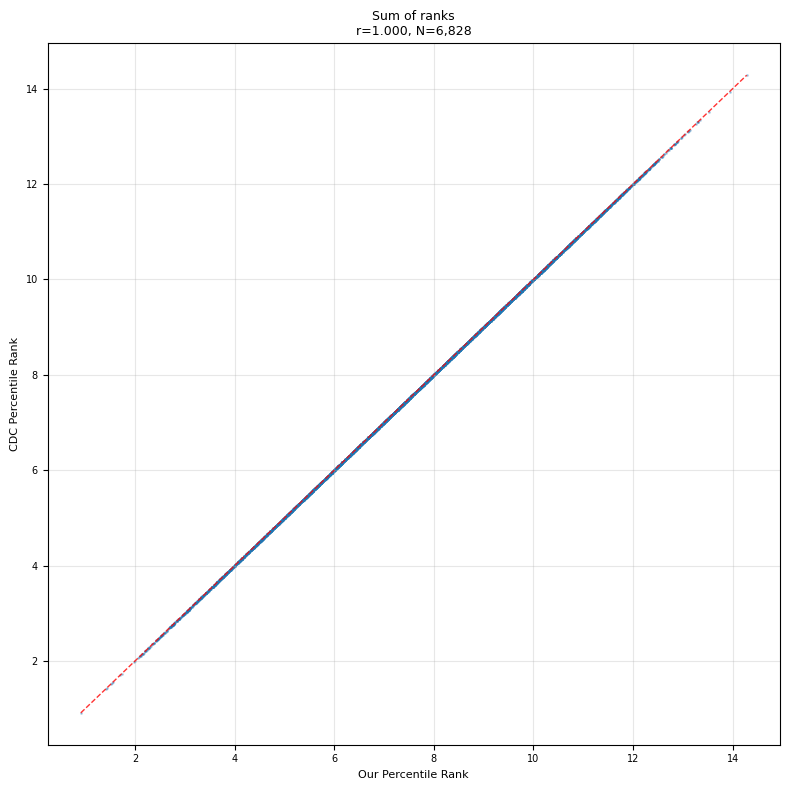

In [32]:
# Create single plot for the last variable comparison (CDC_pr_sum vs SPL_THEMES_v2)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Get the last row from the data dictionary (CDC_pr_sum vs SPL_THEMES_v2)
last_row = svi_data_dict.iloc[-1]
variable_code = last_row['Variable_Code']
cdc_variable = last_row['CDC_Variable']
description = last_row['Description']

print(f"Creating plot for: {description}")
print(f"Our variable: {variable_code}")
print(f"CDC variable: {cdc_variable}")

# Create the comparison plot
correlation, n_valid = create_svi_comparison_plot(
    variable_code, cdc_variable, description, 
    ax, Tract_df_v3
)

print(f"Correlation: {correlation:.4f}")
print(f"Valid observations: {n_valid:,}")

plt.tight_layout()
plt.show()

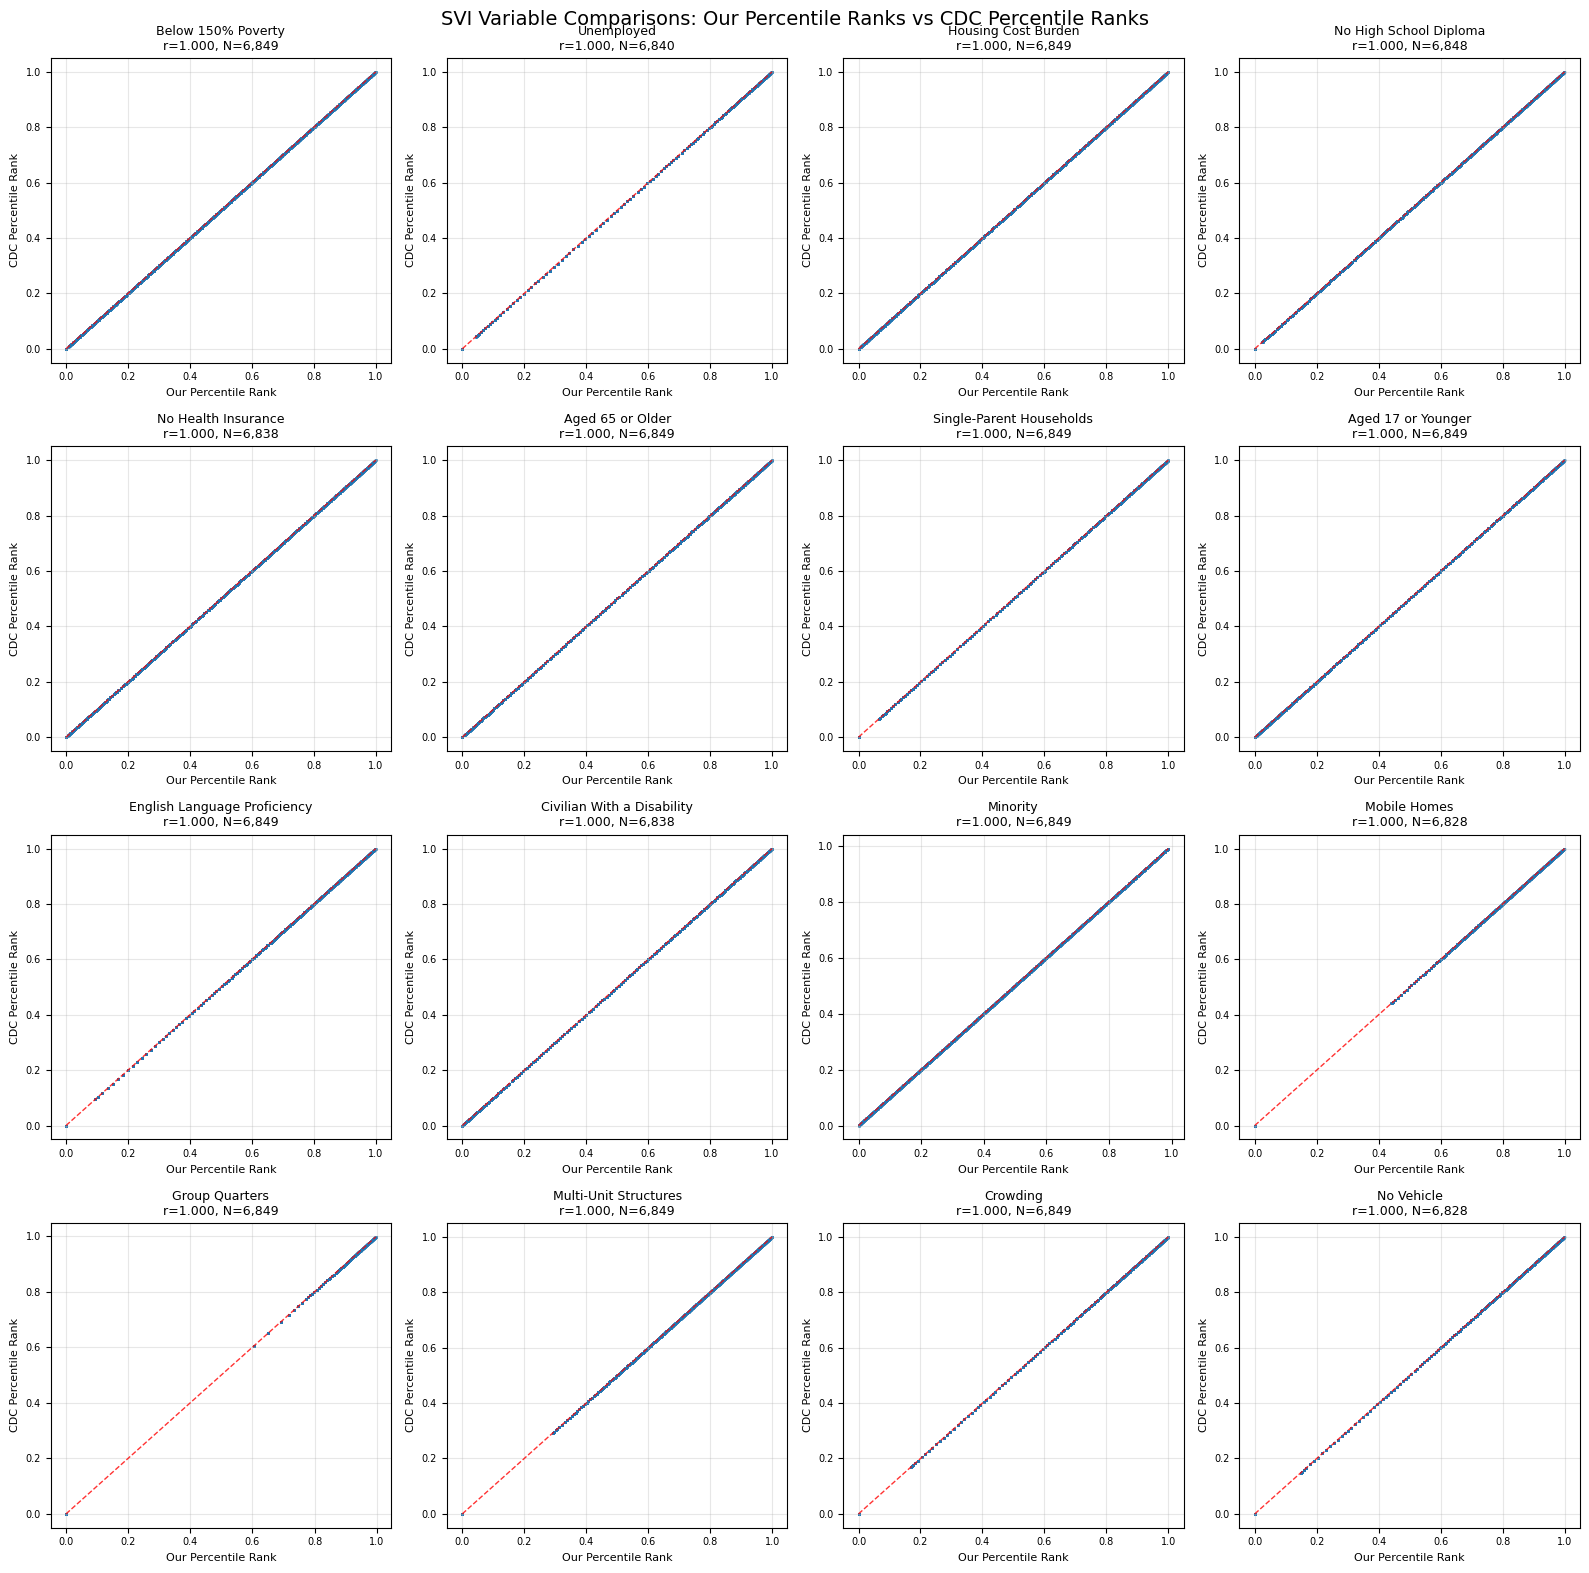


Summary of Correlations:
                    Variable  Correlation  Valid_N
          Below 150% Poverty          1.0     6849
                  Unemployed          1.0     6840
         Housing Cost Burden          1.0     6849
      No High School Diploma          1.0     6848
         No Health Insurance          1.0     6838
            Aged 65 or Older          1.0     6849
    Single-Parent Households          1.0     6849
          Aged 17 or Younger          1.0     6849
English Language Proficiency          1.0     6849
  Civilian With a Disability          1.0     6838
                    Minority          1.0     6849
                Mobile Homes          1.0     6828
              Group Quarters          1.0     6849
       Multi-Unit Structures          1.0     6849
                    Crowding          1.0     6849
                  No Vehicle          1.0     6828

Mean Correlation: 1.0000
Min Correlation: 1.0000
Max Correlation: 1.0000


In [33]:
# Create 4x4 subplot matrix for all SVI variable comparisons
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('SVI Variable Comparisons: Our Percentile Ranks vs CDC Percentile Ranks', fontsize=14, y=0.98)

# Use the data dictionary to loop through variables
comparison_results = []

for i, (index, row) in enumerate(svi_data_dict.iterrows()):
    if i >= 16:  # Only process first 16 variables (excluding the sum)
        break
        
    variable_code = row['Variable_Code']
    cdc_variable = row['CDC_Variable']
    description = row['Description']
    
    # Calculate subplot position
    row_idx = i // 4
    col_idx = i % 4
    
    # Create the comparison plot
    correlation, n_valid = create_svi_comparison_plot(
        variable_code, cdc_variable, description, 
        axes[row_idx, col_idx], Tract_df_v3
    )
    
    # Store results
    comparison_results.append({
        'Variable': description,
        'Our_Var': variable_code,
        'CDC_Var': cdc_variable,
        'Correlation': correlation,
        'Valid_N': n_valid
    })

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

# Display summary of correlations
results_df = pd.DataFrame(comparison_results)
print("\nSummary of Correlations:")
print("="*50)
print(results_df[['Variable', 'Correlation', 'Valid_N']].to_string(index=False))
print(f"\nMean Correlation: {results_df['Correlation'].mean():.4f}")
print(f"Min Correlation: {results_df['Correlation'].min():.4f}")
print(f"Max Correlation: {results_df['Correlation'].max():.4f}")

### Side note - how many tracts in SETX do not have mobile homes or group quarters

In [36]:
Tract_df_v3.head()

,TRACT2020,C202020010pr,C202020020pr,C202020031pr,C202020050pr,C202021010pr,C202030010pr,C202033010pr,C202033020pr,C202060010pr,...,EPL_MINRTY,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEMES,SPL_THEMES_v2,RPL_THEMES,SPL_diff
0,48189950200,0.7668,0.5858,0.2054,0.7666,0.9200,0.3180,0.9920,0.9216,0.7989,...,0.7989,0.4920,0.7155,0.8947,0.8296,0.8975,11.2664,11.2664,0.9360,0.0005
1,48219950400,0.7683,0.8883,0.5064,0.5860,0.9449,0.7115,0.8766,0.7565,0.6741,...,0.6741,0.3132,0.8458,0.6527,0.8478,0.8677,11.7302,11.7302,0.9648,0.0008
2,48219950300,0.6843,0.6146,0.4576,0.7403,0.7525,0.5925,0.5466,0.2767,0.5148,...,0.5147,0.3957,0.7609,0.7732,0.6939,0.8207,9.7683,9.7683,0.7790,0.0010
3,48219950100,0.6783,0.8297,0.1967,0.6142,0.8236,0.7573,0.2633,0.5686,0.4595,...,0.4594,0.0000,0.7300,0.6595,0.7104,0.0000,8.8544,8.8544,0.6575,0.0009
4,48219950600,0.6157,0.0974,0.2332,0.7403,0.5714,0.5201,0.5466,0.8449,0.2510,...,0.2509,0.2972,0.8537,0.4825,0.2683,0.0000,7.2693,7.2693,0.4465,0.0012


In [39]:
Tract_df[['TRACT2020']].describe()

,TRACT2020
count,6896
unique,6896
top,48189950200
freq,1


In [41]:
Tract_df[['C202070010', 'C202070020']].describe().T

,count,mean,std,min,25%,50%,75%,max
C202070010,6828.0,0.074262,0.123817,0.0,0.0,0.009,0.104,1.0
C202070020,6884.0,0.021016,0.092755,0.0,0.0,0.000,0.006,1.0


In [43]:
# in Tract_df how many tracts have no mobile homes or group quarters
condition1 = Tract_df['C202070010'] == 0
condition2 = Tract_df['C202070020'] == 0
print("Number of tracts with no mobile homes", len(Tract_df[condition1]))
print("Number of tracts with no group quarters", len(Tract_df[condition2]))

Number of tracts with no mobile homes 3009
Number of tracts with no group quarters 4184


In [45]:
Tract_df[['TRACT2020']][Tract_df['SETX'] == 1].describe()

,TRACT2020
count,128
unique,128
top,48351950100
freq,1


In [44]:
# in Tract_df how many tracts have no mobile homes or group quarters
condition1 = Tract_df['C202070010'] == 0
condition2 = Tract_df['C202070020'] == 0
condition3 = Tract_df['SETX'] == 1
print("Number of tracts with no mobile homes in SETX", len(Tract_df[condition1 & condition3]))
print("Number of tracts with no group quarters in SETX", len(Tract_df[condition2 & condition3]))

Number of tracts with no mobile homes in SETX 34
Number of tracts with no group quarters in SETX 64


In [48]:
34/128

0.265625

In [49]:
64/128

0.5

In [51]:
Tract_df_v2[['C202070010','C202070010pr']][~condition1 & condition3].describe().T

,count,mean,std,min,25%,50%,75%,max
C202070010,91.0,0.164165,0.134677,0.0030,0.03450,0.1330,0.28650,0.5110
C202070010pr,91.0,0.764705,0.161750,0.4451,0.62825,0.7863,0.92135,0.9873


In [52]:
Tract_df_v2[['C202070020','C202070020pr']][~condition2 & condition3].describe().T

,count,mean,std,min,25%,50%,75%,max
C202070020,64.0,0.063656,0.180426,0.0010,0.0040,0.0145,0.042500,1.0000
C202070020pr,64.0,0.814252,0.114381,0.6059,0.7178,0.8172,0.922525,0.9971


In [34]:
# calculate CDC SVI value
column = 'CDC_pr_sum'
Tract_df_v3[column].describe()

count    6828.000000
mean        7.621013
std         2.448539
min         0.912300
25%         5.750200
50%         7.620900
75%         9.575450
max        14.283200
Name: CDC_pr_sum, dtype: float64

In [35]:
# how many values non missing values are in the column
condition1 = Tract_df_v3[column].isna()
condition = ~condition1
df_v2 = Tract_df_v3[condition].copy(deep = True)
length = len(df_v2)
df_v2[f'{column}_rank'] = stats.rankdata(df_v2[column], method='min', nan_policy='omit')
df_v2[f'{column}pr'] = df_v2[f'{column}_rank'] / length
# round to the fourth decimal place
df_v2[f'{column}pr'] = df_v2[f'{column}pr'].round(4)
df_v2[f'{column}pr'].describe()

count    6828.000000
mean        0.500070
std         0.288696
min         0.000100
25%         0.250000
50%         0.500050
75%         0.750025
max         1.000000
Name: CDC_pr_sumpr, dtype: float64

Correlation between our calculated overall SVI and CDC overall SVI: 1.0000
Number of valid comparisons: 6,828
Mean difference (Our - CDC): 0.0001
Mean absolute difference: 0.0001


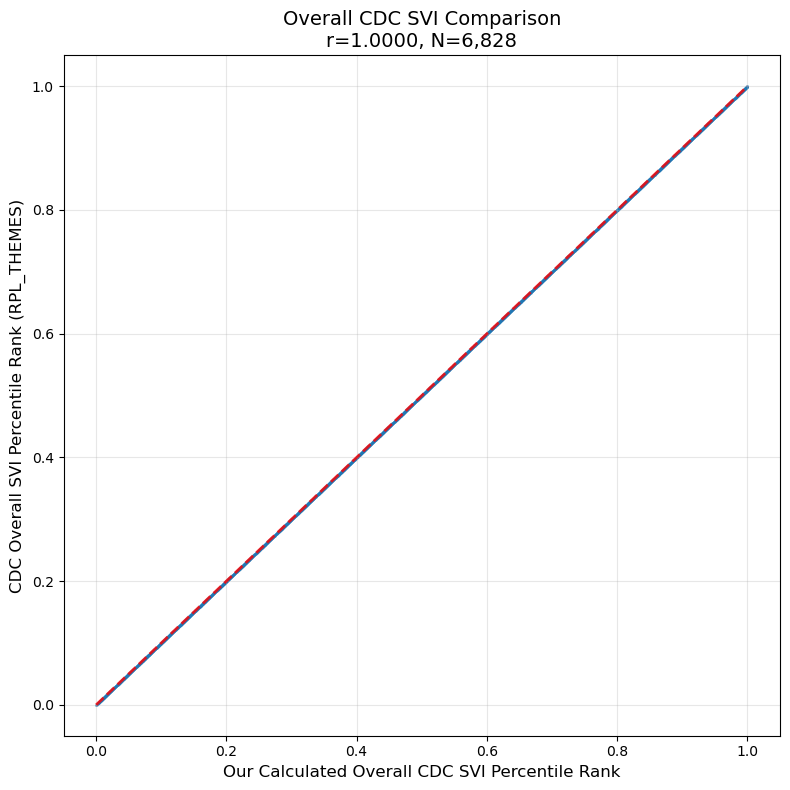

In [36]:
# compare 'CDC_pr_sum_pr' with 'RPL_THEMES'
# First merge the calculated percentile rank back to the main dataframe
Tract_df_v3 = Tract_df_v3.merge(df_v2[['TRACT2020', 'CDC_pr_sumpr']], on='TRACT2020', how='left')

# Replace -999 with NaN in CDC data
Tract_df_v3['RPL_THEMES_clean'] = Tract_df_v3['RPL_THEMES'].replace(-999, np.nan)

# Create comparison plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Filter for valid comparisons
valid_mask = Tract_df_v3[f'{column}pr'].notna() & Tract_df_v3['RPL_THEMES_clean'].notna()
df_valid = Tract_df_v3[valid_mask]

if len(df_valid) > 0:
    # Calculate correlation
    correlation = df_valid[f'{column}pr'].corr(df_valid['RPL_THEMES_clean'])
    
    # Create scatter plot
    ax.scatter(df_valid[f'{column}pr'], df_valid['RPL_THEMES_clean'], alpha=0.3, s=1)
    
    # Add perfect correlation line (y=x)
    min_val = min(df_valid[f'{column}pr'].min(), df_valid['RPL_THEMES_clean'].min())
    max_val = max(df_valid[f'{column}pr'].max(), df_valid['RPL_THEMES_clean'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
    
    ax.set_xlabel('Our Calculated Overall CDC SVI Percentile Rank', fontsize=12)
    ax.set_ylabel('CDC Overall SVI Percentile Rank (RPL_THEMES)', fontsize=12)
    ax.set_title(f'Overall CDC SVI Comparison\nr={correlation:.4f}, N={len(df_valid):,}', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    print(f"Correlation between our calculated overall SVI and CDC overall SVI: {correlation:.4f}")
    print(f"Number of valid comparisons: {len(df_valid):,}")
    
    # Calculate some summary statistics
    mean_diff = (df_valid[f'{column}pr'] - df_valid['RPL_THEMES_clean']).mean()
    abs_mean_diff = (df_valid[f'{column}pr'] - df_valid['RPL_THEMES_clean']).abs().mean()
    
    print(f"Mean difference (Our - CDC): {mean_diff:.4f}")
    print(f"Mean absolute difference: {abs_mean_diff:.4f}")
    
else:
    ax.text(0.5, 0.5, 'No valid data for comparison', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Overall SVI Comparison\nNo valid data')

plt.tight_layout()
plt.show()


## Now that CDC is replicated - Apply to HRRC and SVInsight

In [115]:
# collect variables that start with C20202 or C20203 or C20204 or C20205 or C20206 or C20207 or C20208 and end with pr
pr_vars = [col for col in Tract_df_v2.columns if (col.startswith('H20202') or 
                                                  col.startswith('H20203') or 
                                                  col.startswith('H20204') or 
                                                  col.startswith('H20205') or 
                                                  col.startswith('H20206') or 
                                                  col.startswith('H20207') or 
                                                  col.startswith('H20208')) and 
                                                  col.endswith('pr')]
pr_vars

['H202020010pr',
 'H202020012pr',
 'H202020020pr',
 'H202020040pr',
 'H202021010pr',
 'H202030011pr',
 'H202033010pr',
 'H202033025pr',
 'H202060010pr',
 'H202062010pr',
 'H202070010pr',
 'H202070020pr',
 'H202070030pr',
 'H202070040pr',
 'H202070070pr',
 'H202072010pr',
 'H202072020pr',
 'H202081011pr']

In [116]:
# drop Median Home Value H202020040, No Broadband Internet H202081011 and Gross Rent H202081030 from list
variables_to_remove = ['H202020040pr', 'H202081030pr', 'H202081011pr']
pr_vars = [var for var in pr_vars if var not in variables_to_remove]

print(f"Removed variables: {variables_to_remove}")
print(f"Remaining HRRC variables: {len(pr_vars)}")
print("Updated pr_vars list:")
for var in pr_vars:
    print(f"  - {var}")


Removed variables: ['H202020040pr', 'H202081030pr', 'H202081011pr']
Remaining HRRC variables: 16
Updated pr_vars list:
  - H202020010pr
  - H202020012pr
  - H202020020pr
  - H202021010pr
  - H202030011pr
  - H202033010pr
  - H202033025pr
  - H202060010pr
  - H202062010pr
  - H202070010pr
  - H202070020pr
  - H202070030pr
  - H202070040pr
  - H202070070pr
  - H202072010pr
  - H202072020pr


In [39]:
# create new variable that sums the pr variables
# First, create sum but set to NaN if any pr_vars are missing (following CDC methodology)
Tract_df_v2['HRRC_pr_sum'] = Tract_df_v2[pr_vars].sum(axis=1)

# Replace HRRC_pr_sum with missing if any of the pr_vars are missing
# Check if any variables are missing for each row
missing_any = Tract_df_v2[pr_vars].isna().any(axis=1)
Tract_df_v2.loc[missing_any, 'HRRC_pr_sum'] = np.nan

print(f"Total tracts: {len(Tract_df_v2):,}")
print(f"Tracts with missing HRRC_pr_sum: {Tract_df_v2['HRRC_pr_sum'].isna().sum():,}")
print(f"Tracts with complete HRRC_pr_sum: {Tract_df_v2['HRRC_pr_sum'].notna().sum():,}")

# describe CDC_pr_sum
Tract_df_v2['HRRC_pr_sum'].describe()

Total tracts: 6,896
Tracts with missing HRRC_pr_sum: 47
Tracts with complete HRRC_pr_sum: 6,849


count    6849.000000
mean        7.529384
std         2.375871
min         1.066600
25%         5.746300
50%         7.545400
75%         9.328200
max        14.558700
Name: HRRC_pr_sum, dtype: float64

In [40]:
# calculate CDC SVI value
column = 'HRRC_pr_sum'
Tract_df_v2[column].describe()

count    6849.000000
mean        7.529384
std         2.375871
min         1.066600
25%         5.746300
50%         7.545400
75%         9.328200
max        14.558700
Name: HRRC_pr_sum, dtype: float64

In [41]:
# replicate HRRC with CDC method SVI value
column = 'HRRC_pr_sum'
# how many values non missing values are in the column
condition1 = Tract_df_v2[column].isna()
condition = ~condition1
HRRC_df = Tract_df_v2[condition].copy(deep = True)
length = len(HRRC_df)
HRRC_df[f'{column}_rank'] = stats.rankdata(HRRC_df[column], method='min', nan_policy='omit')
HRRC_df[f'{column}pr'] = HRRC_df[f'{column}_rank'] / length
# round to the fourth decimal place
HRRC_df[f'{column}pr'] = HRRC_df[f'{column}pr'].round(4) *100
HRRC_df[f'{column}pr'].describe()

count    6849.000000
mean       50.006909
std        28.869578
min         0.010000
25%        25.010000
50%        50.010000
75%        75.000000
max       100.000000
Name: HRRC_pr_sumpr, dtype: float64

In [42]:
HRRC_df['H202090012'].describe()

count    6849.000000
mean       50.268930
std        28.678746
min         0.700000
25%        25.500000
50%        50.200000
75%        75.100000
max       100.000000
Name: H202090012, dtype: float64

Correlation between our calculated overall SVI and HRRC overall SVI: 0.9772
Number of valid comparisons: 6,849
Mean difference (Our - HRRC): -0.2620
Mean absolute difference: 4.6652


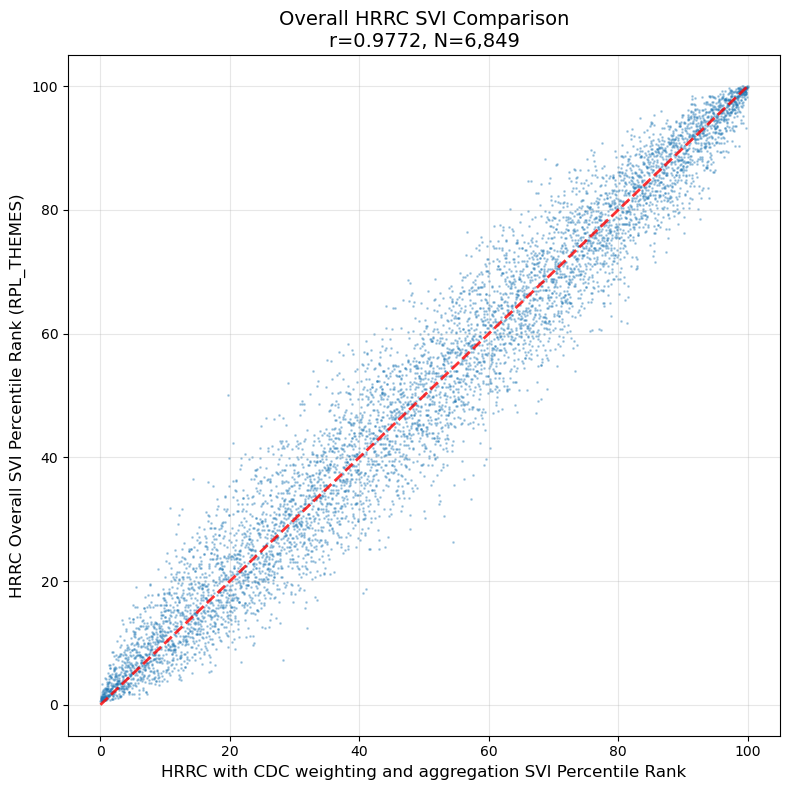

In [43]:
# compare HRRC_df['HRRC_pr_sumpr'] with HRRC_df['H202090012']
column = 'HRRC_pr_sum'
# Create comparison plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
# Filter for valid comparisons
valid_mask = HRRC_df[f'{column}pr'].notna() & HRRC_df['H202090012'].notna()
df_valid = HRRC_df[valid_mask]

if len(df_valid) > 0:
    # Calculate correlation
    correlation = df_valid[f'{column}pr'].corr(df_valid['H202090012'])
    
    # Create scatter plot
    ax.scatter(df_valid[f'{column}pr'], df_valid['H202090012'], alpha=0.3, s=1)
    
    # Add perfect correlation line (y=x)
    min_val = min(df_valid[f'{column}pr'].min(), df_valid['H202090012'].min())
    max_val = max(df_valid[f'{column}pr'].max(), df_valid['H202090012'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
    
    ax.set_xlabel('HRRC with CDC weighting and aggregation SVI Percentile Rank', fontsize=12)
    ax.set_ylabel('HRRC Overall SVI Percentile Rank (RPL_THEMES)', fontsize=12)
    ax.set_title(f'Overall HRRC SVI Comparison\nr={correlation:.4f}, N={len(df_valid):,}', fontsize=14)
    ax.grid(True, alpha=0.3)

    print(f"Correlation between our calculated overall SVI and HRRC overall SVI: {correlation:.4f}")
    print(f"Number of valid comparisons: {len(df_valid):,}")
    
    # Calculate some summary statistics
    mean_diff = (df_valid[f'{column}pr'] - df_valid['H202090012']).mean()
    abs_mean_diff = (df_valid[f'{column}pr'] - df_valid['H202090012']).abs().mean()

    print(f"Mean difference (Our - HRRC): {mean_diff:.4f}")
    print(f"Mean absolute difference: {abs_mean_diff:.4f}")
    
else:
    ax.text(0.5, 0.5, 'No valid data for comparison', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Overall SVI Comparison\nNo valid data')

plt.tight_layout()
plt.show()




In [117]:
# create new variable that sums the pr variables
# First, create sum but set to NaN if any pr_vars are missing (following CDC methodology)
BG_df_v2['HRRC_pr_sum'] = BG_df_v2[pr_vars].sum(axis=1)

# Replace HRRC_pr_sum with missing if any of the pr_vars are missing
# Check if any variables are missing for each row
missing_any = BG_df_v2[pr_vars].isna().any(axis=1)
BG_df_v2.loc[missing_any, 'HRRC_pr_sum'] = np.nan

print(f"Total tracts: {len(BG_df_v2):,}")
print(f"Tracts with missing HRRC_pr_sum: {BG_df_v2['HRRC_pr_sum'].isna().sum():,}")
print(f"Tracts with complete HRRC_pr_sum: {BG_df_v2['HRRC_pr_sum'].notna().sum():,}")

# describe CDC_pr_sum
BG_df_v2['HRRC_pr_sum'].describe()

Total tracts: 18,638
Tracts with missing HRRC_pr_sum: 141
Tracts with complete HRRC_pr_sum: 18,497


count    18497.000000
mean         6.861755
std          2.225098
min          0.000000
25%          5.237700
50%          6.849100
75%          8.507600
max         13.417400
Name: HRRC_pr_sum, dtype: float64

In [118]:
# replicate HRRC with CDC method SVI value
column = 'HRRC_pr_sum'
# how many values non missing values are in the column
condition1 = BG_df_v2[column].isna()
condition = ~condition1
HRRC_BG_df = BG_df_v2[condition].copy(deep = True)
length = len(HRRC_BG_df)
HRRC_BG_df[f'{column}_rank'] = stats.rankdata(HRRC_BG_df[column], method='min', nan_policy='omit')
HRRC_BG_df[f'{column}pr'] = HRRC_BG_df[f'{column}_rank'] / length
# round to the fourth decimal place
HRRC_BG_df[f'{column}pr'] = HRRC_BG_df[f'{column}pr'].round(4) *100
HRRC_BG_df[f'{column}pr'].describe()

count    18497.000000
mean        50.002306
std         28.868296
min          0.010000
25%         25.000000
50%         50.000000
75%         75.000000
max        100.000000
Name: HRRC_pr_sumpr, dtype: float64

Correlation between our calculated overall SVI and HRRC overall SVI: 0.9637
Number of valid comparisons: 18,497
Mean difference (Our - HRRC): -0.3042
Mean absolute difference: 5.8748


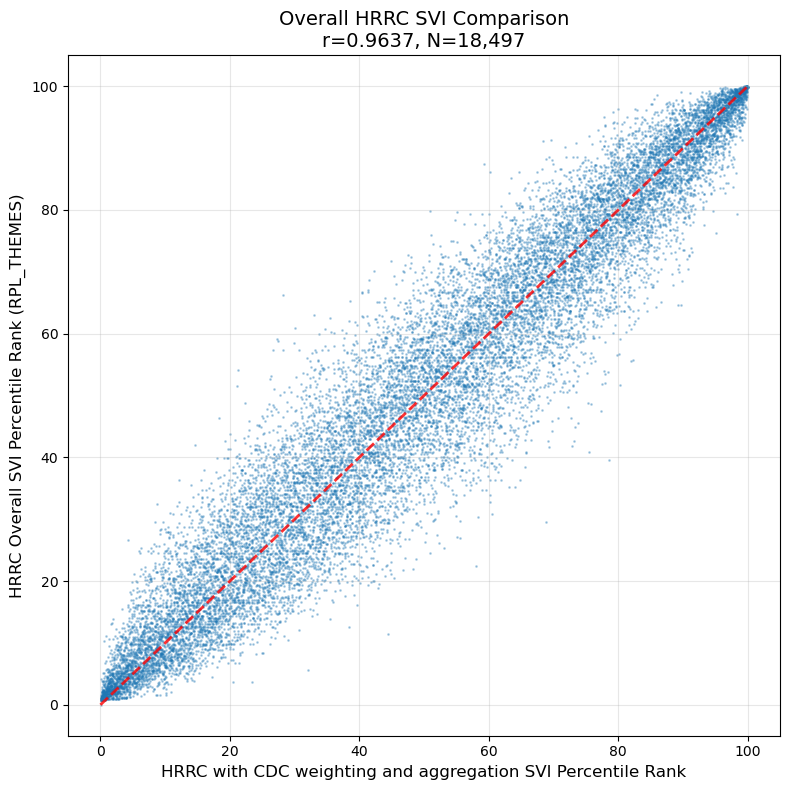

In [119]:
# compare HRRC_df['HRRC_pr_sumpr'] with HRRC_df['H202090012']
column = 'HRRC_pr_sum'
# Create comparison plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
# Filter for valid comparisons
valid_mask = HRRC_BG_df[f'{column}pr'].notna() & HRRC_BG_df['H202090012'].notna()
df_valid = HRRC_BG_df[valid_mask]

if len(df_valid) > 0:
    # Calculate correlation
    correlation = df_valid[f'{column}pr'].corr(df_valid['H202090012'])
    
    # Create scatter plot
    ax.scatter(df_valid[f'{column}pr'], df_valid['H202090012'], alpha=0.3, s=1)
    
    # Add perfect correlation line (y=x)
    min_val = min(df_valid[f'{column}pr'].min(), df_valid['H202090012'].min())
    max_val = max(df_valid[f'{column}pr'].max(), df_valid['H202090012'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
    
    ax.set_xlabel('HRRC with CDC weighting and aggregation SVI Percentile Rank', fontsize=12)
    ax.set_ylabel('HRRC Overall SVI Percentile Rank (RPL_THEMES)', fontsize=12)
    ax.set_title(f'Overall HRRC SVI Comparison\nr={correlation:.4f}, N={len(df_valid):,}', fontsize=14)
    ax.grid(True, alpha=0.3)

    print(f"Correlation between our calculated overall SVI and HRRC overall SVI: {correlation:.4f}")
    print(f"Number of valid comparisons: {len(df_valid):,}")
    
    # Calculate some summary statistics
    mean_diff = (df_valid[f'{column}pr'] - df_valid['H202090012']).mean()
    abs_mean_diff = (df_valid[f'{column}pr'] - df_valid['H202090012']).abs().mean()

    print(f"Mean difference (Our - HRRC): {mean_diff:.4f}")
    print(f"Mean absolute difference: {abs_mean_diff:.4f}")
    
else:
    ax.text(0.5, 0.5, 'No valid data for comparison', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Overall SVI Comparison\nNo valid data')

plt.tight_layout()
plt.show()

### Update UT with CDC weight and aggregation

In [44]:
# collect variables that start with C20202 or C20203 or C20204 or C20205 or C20206 or C20207 or C20208 and end with pr
pr_vars = [col for col in Tract_df_v2.columns if (col.startswith('U20202') or 
                                                  col.startswith('U20203') or 
                                                  col.startswith('U20204') or 
                                                  col.startswith('U20205') or 
                                                  col.startswith('U20206') or 
                                                  col.startswith('U20207') or 
                                                  col.startswith('U20208')) and 
                                                  col.endswith('pr')]
pr_vars

['U202020010pr',
 'U202020013pr',
 'U202020020pr',
 'U202020031pr',
 'U202020033pr',
 'U202020040pr',
 'U202020070pr',
 'U202021010pr',
 'U202030020pr',
 'U202030030pr',
 'U202033010pr',
 'U202060021pr',
 'U202060022pr',
 'U202060023pr',
 'U202060024pr',
 'U202062010pr',
 'U202065010pr',
 'U202065015pr',
 'U202065017pr',
 'U202070010pr',
 'U202070030pr',
 'U202070040pr',
 'U202070060pr',
 'U202072010pr',
 'U202020050pr',
 'U202081021pr',
 'U202081022pr']

In [48]:
len(pr_vars)

27

In [49]:
# create new variable that sums the pr variables
# First, create sum but set to NaN if any pr_vars are missing (following CDC methodology)
Tract_df_v2['UT_pr_sum'] = Tract_df_v2[pr_vars].sum(axis=1)

# Replace HRRC_pr_sum with missing if any of the pr_vars are missing
# Check if any variables are missing for each row
missing_any = Tract_df_v2[pr_vars].isna().any(axis=1)
Tract_df_v2.loc[missing_any, 'UT_pr_sum'] = np.nan

print(f"Total tracts: {len(Tract_df_v2):,}")
print(f"Tracts with missing UT_pr_sum: {Tract_df_v2['UT_pr_sum'].isna().sum():,}")
print(f"Tracts with complete UT_pr_sum: {Tract_df_v2['UT_pr_sum'].notna().sum():,}")

# describe CDC_pr_sum
Tract_df_v2['UT_pr_sum'].describe()

Total tracts: 6,896
Tracts with missing UT_pr_sum: 92
Tracts with complete UT_pr_sum: 6,804


count    6804.000000
mean       12.934529
std         2.937984
min         4.846400
25%        10.759000
50%        13.138750
75%        15.217125
max        20.300900
Name: UT_pr_sum, dtype: float64

In [51]:
Tract_df_v2['U202090012'].describe()

count    6825.000000
mean       50.007326
std        28.869628
min         0.015000
25%        25.011000
50%        50.007000
75%        75.004000
max       100.000000
Name: U202090012, dtype: float64

In [52]:
# replicate HRRC with CDC method SVI value
column = 'UT_pr_sum'
# how many values non missing values are in the column
condition1 = Tract_df_v2[column].isna()
condition = ~condition1
UT_df = Tract_df_v2[condition].copy(deep = True)
length = len(UT_df)
UT_df[f'{column}_rank'] = stats.rankdata(UT_df[column], method='min', nan_policy='omit')
UT_df[f'{column}pr'] = UT_df[f'{column}_rank'] / length
# round to the fourth decimal place
UT_df[f'{column}pr'] = UT_df[f'{column}pr'].round(4) *100
UT_df[f'{column}pr'].describe()

count    6804.000000
mean       50.007115
std        28.869630
min         0.010000
25%        25.007500
50%        50.005000
75%        75.002500
max       100.000000
Name: UT_pr_sumpr, dtype: float64

Correlation between our calculated overall SVI and SVInsight overall SVI: 0.8082
Number of valid comparisons: 6,804
Mean difference (Our - SVInsight): -0.0393
Mean absolute difference: 13.5898


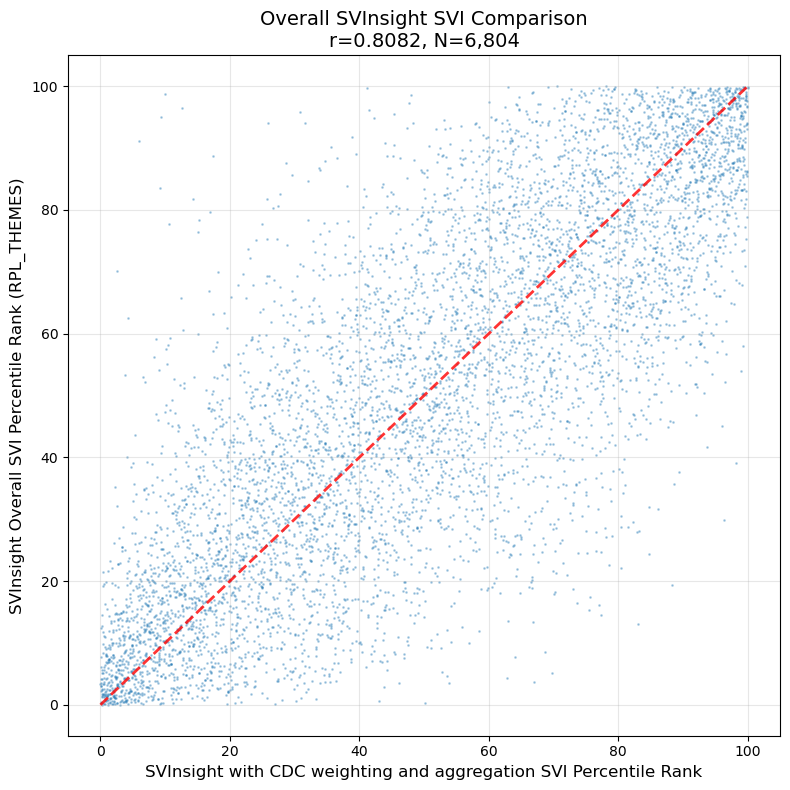

In [53]:
# compare UT_df['UT_pr_sum'] with UT_df['U202090012']
column = 'UT_pr_sum'
# Create comparison plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
# Filter for valid comparisons
valid_mask = UT_df[f'{column}pr'].notna() & UT_df['U202090012'].notna()
df_valid = UT_df[valid_mask]

if len(df_valid) > 0:
    # Calculate correlation
    correlation = df_valid[f'{column}pr'].corr(df_valid['U202090012'])
    
    # Create scatter plot
    ax.scatter(df_valid[f'{column}pr'], df_valid['U202090012'], alpha=0.3, s=1)
    
    # Add perfect correlation line (y=x)
    min_val = min(df_valid[f'{column}pr'].min(), df_valid['U202090012'].min())
    max_val = max(df_valid[f'{column}pr'].max(), df_valid['U202090012'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
    
    ax.set_xlabel('SVInsight with CDC weighting and aggregation SVI Percentile Rank', fontsize=12)
    ax.set_ylabel('SVInsight Overall SVI Percentile Rank (RPL_THEMES)', fontsize=12)
    ax.set_title(f'Overall SVInsight SVI Comparison\nr={correlation:.4f}, N={len(df_valid):,}', fontsize=14)
    ax.grid(True, alpha=0.3)

    print(f"Correlation between our calculated overall SVI and SVInsight overall SVI: {correlation:.4f}")
    print(f"Number of valid comparisons: {len(df_valid):,}")
    
    # Calculate some summary statistics
    mean_diff = (df_valid[f'{column}pr'] - df_valid['U202090012']).mean()
    abs_mean_diff = (df_valid[f'{column}pr'] - df_valid['U202090012']).abs().mean()

    print(f"Mean difference (Our - SVInsight): {mean_diff:.4f}")
    print(f"Mean absolute difference: {abs_mean_diff:.4f}")
    
else:
    ax.text(0.5, 0.5, 'No valid data for comparison', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Overall SVI Comparison\nNo valid data')

plt.tight_layout()
plt.show()

In [109]:
# create new variable that sums the pr variables
# First, create sum but set to NaN if any pr_vars are missing (following CDC methodology)
BG_df_v2['UT_pr_sum'] = BG_df_v2[pr_vars].sum(axis=1)

# Replace HRRC_pr_sum with missing if any of the pr_vars are missing
# Check if any variables are missing for each row
missing_any = BG_df_v2[pr_vars].isna().any(axis=1)
BG_df_v2.loc[missing_any, 'UT_pr_sum'] = np.nan

print(f"Total tracts: {len(BG_df_v2):,}")
print(f"Tracts with missing UT_pr_sum: {BG_df_v2['UT_pr_sum'].isna().sum():,}")
print(f"Tracts with complete UT_pr_sum: {BG_df_v2['UT_pr_sum'].notna().sum():,}")

# describe CDC_pr_sum
BG_df_v2['UT_pr_sum'].describe()

Total tracts: 18,638
Tracts with missing UT_pr_sum: 528
Tracts with complete UT_pr_sum: 18,110


count    18110.000000
mean        12.227754
std          2.718830
min          2.556200
25%         10.306600
50%         12.382000
75%         14.265175
max         19.721500
Name: UT_pr_sum, dtype: float64

In [110]:
# replicate HRRC with CDC method SVI value
column = 'UT_pr_sum'
# how many values non missing values are in the column
condition1 = BG_df_v2[column].isna()
condition = ~condition1
UT_BG_df = BG_df_v2[condition].copy(deep = True)
length = len(UT_BG_df)
UT_BG_df[f'{column}_rank'] = stats.rankdata(UT_BG_df[column], method='min', nan_policy='omit')
UT_BG_df[f'{column}pr'] = UT_BG_df[f'{column}_rank'] / length
# round to the fourth decimal place
UT_BG_df[f'{column}pr'] = UT_BG_df[f'{column}pr'].round(4) *100
UT_BG_df[f'{column}pr'].describe()

count    18110.000000
mean        50.002527
std         28.868310
min          0.010000
25%         25.002500
50%         50.005000
75%         75.000000
max        100.000000
Name: UT_pr_sumpr, dtype: float64

Correlation between our calculated overall SVI and SVInsight overall SVI: 0.7932
Number of valid comparisons: 18,110
Mean difference (Our - SVInsight): 0.0504
Mean absolute difference: 14.0350


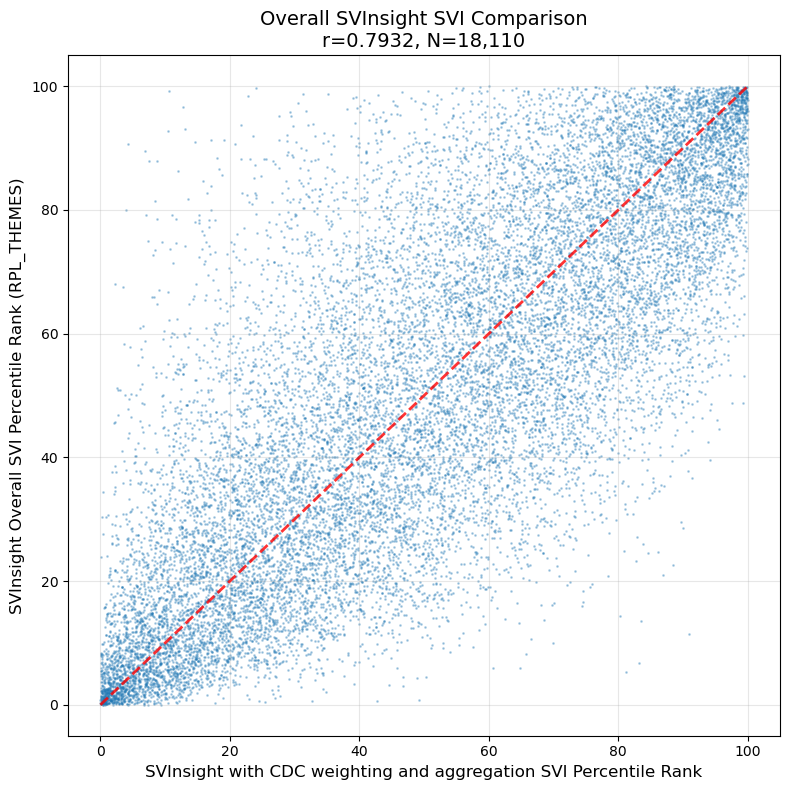

In [111]:
# compare UT_df['UT_pr_sum'] with UT_df['U202090012']
column = 'UT_pr_sum'
# Create comparison plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
# Filter for valid comparisons
valid_mask = UT_BG_df[f'{column}pr'].notna() & UT_BG_df['U202090012'].notna()
df_valid = UT_BG_df[valid_mask]

if len(df_valid) > 0:
    # Calculate correlation
    correlation = df_valid[f'{column}pr'].corr(df_valid['U202090012'])
    
    # Create scatter plot
    ax.scatter(df_valid[f'{column}pr'], df_valid['U202090012'], alpha=0.3, s=1)
    
    # Add perfect correlation line (y=x)
    min_val = min(df_valid[f'{column}pr'].min(), df_valid['U202090012'].min())
    max_val = max(df_valid[f'{column}pr'].max(), df_valid['U202090012'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
    
    ax.set_xlabel('SVInsight with CDC weighting and aggregation SVI Percentile Rank', fontsize=12)
    ax.set_ylabel('SVInsight Overall SVI Percentile Rank (RPL_THEMES)', fontsize=12)
    ax.set_title(f'Overall SVInsight SVI Comparison\nr={correlation:.4f}, N={len(df_valid):,}', fontsize=14)
    ax.grid(True, alpha=0.3)

    print(f"Correlation between our calculated overall SVI and SVInsight overall SVI: {correlation:.4f}")
    print(f"Number of valid comparisons: {len(df_valid):,}")
    
    # Calculate some summary statistics
    mean_diff = (df_valid[f'{column}pr'] - df_valid['U202090012']).mean()
    abs_mean_diff = (df_valid[f'{column}pr'] - df_valid['U202090012']).abs().mean()

    print(f"Mean difference (Our - SVInsight): {mean_diff:.4f}")
    print(f"Mean absolute difference: {abs_mean_diff:.4f}")
    
else:
    ax.text(0.5, 0.5, 'No valid data for comparison', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Overall SVI Comparison\nNo valid data')

plt.tight_layout()
plt.show()

## Make charts for SETX 

In [70]:
def select_svi_vars_v2(df, airsite_var):
    df_dict = {}
    # select southeast texas counties
    df_dict['SETX'] = df[df['SETX'] == 1].copy(deep=True)

    df_dict['sites'] = df_dict['SETX'][df_dict['SETX'][airsite_var] == 1].copy(deep=True)

    return df_dict

def axes_plot(num = 0, 
              axes = None,
              df_dict = {}, 
              svi1 = 'C202090012', 
              svi2 = 'H202090012', 
              title = 'CDC vs HRRC Census Tract', 
              label1 = 'CDC', 
              label2 = 'HRRC',
              legend1 = 'Tract',
              legend2 = 'Study Site Tract') -> plt.Axes:
    
    df = df_dict['SETX'].copy(deep=True)
    site_df = df_dict['sites'].copy(deep=True)

    # check if missing values
    if site_df[svi1].isnull().any():
        print(f"Missing values in {svi1} for study site tract")
        length = len(site_df[svi1])
        # drop missing values
        site_df = site_df.dropna(subset=[svi1])
        length2 = len(site_df[svi1])
        print(f"Missing values in {svi1} dropped {length - length2} rows")
    if site_df[svi2].isnull().any():
        print(f"Missing values in {svi2} for study site tract")
        length = len(site_df[svi2])
        # drop missing values
        site_df = site_df.dropna(subset=[svi2])
        length2 = len(site_df[svi2])
        print(f"Missing values in {svi2} dropped {length - length2} rows")

    # select west side sites if airsite_name starts with 'W'
    condition = site_df['airsite_name'].str.startswith('W')
    west_side_df = site_df[condition].copy(deep=True)
    # select east side sites if airsite_name starts with 'E'
    condition = site_df['airsite_name'].str.startswith('E')
    east_side_df = site_df[condition].copy(deep=True)

    ax = axes[num]

    # fix the min and max values for the axes to 1
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    # add a diagonal line from (0,0) to (100,100)
    ax.plot([0, 100], [0, 100], color='red', linestyle='--', linewidth=0.25)
    
    # Scatter plot for all of study area
    ax.scatter(df[svi1], df[svi2], alpha=1, marker='+', color='#b2df8a', label =legend1)
    ax.scatter(west_side_df[svi1], west_side_df[svi2], 
                    alpha=1,
                    marker='<',
                    color='#f1a340',
                    edgecolor='black',
                    linewidth=0.5,
                    s=100,
                    label = 'West '+legend2) # increase size of points
    ax.scatter(east_side_df[svi1], east_side_df[svi2], 
                    alpha=1,
                    marker='>',
                    color='#998ec3',
                    edgecolor='black',
                    linewidth=0.5,
                    s=100,
                    label = 'East '+legend2) # increase size of points
    # use airsite name to label points
    for i, row in west_side_df.iterrows():
        ax.text(row[svi1], row[svi2]-2, row['airsite_name'], fontsize=12, ha='center', va='top', weight='normal')
    for i, row in east_side_df.iterrows():
        ax.text(row[svi1], row[svi2]+2, row['airsite_name'], fontsize=12, ha='center', va='bottom', weight='normal')
    ax.set_xlabel(label1)
    ax.set_ylabel(label2)
    ax.set_title(title)

    # add a letter in the top left corner of the plot
    letter = chr(97 + num)  # 97 is the ASCII code for 'a'
    ax.text(-4, 105, letter, fontsize=20, weight='bold', ha='left', va='top')

    # add correlation coefficient to the plot
    corr = df[svi1].corr(df[svi2])
    corr_text = f'Correlation: {corr:.2f}'
    ax.text(100, 20, corr_text, fontsize=12, ha='right', va='bottom', color='black')

    ax.legend(loc='lower right', fontsize=10)
    return ax


def generate_plot(svi_tract_dict,
                    svi_bg_dict, 
                    commonlabel,
                    cdc_varname, 
                    hrrc_varname, 
                    SVInsight_varname, 
                    label_cdc,
                    label_hrrc,
                    label_SVInsight):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes_plot(0, axes=axes, 
                df_dict = svi_tract_dict, 
                svi1=cdc_varname, svi2=hrrc_varname, 
                label1=label_cdc, label2=label_hrrc, 
                title='CDC/ATSDR SVI vs HRRC SVI Census Tract', 
                legend1='SE TX Tract',
                legend2='Study Site Tract')
    axes_plot(1, axes=axes, 
                df_dict = svi_tract_dict, 
                svi1=cdc_varname, svi2=SVInsight_varname, 
                label1=label_cdc, label2=label_SVInsight, 
                title='CDC/ATSDR SVI vs SVInsight Census Tract', 
                legend1='SE TX Tract',
                legend2='Study Site Tract')
    axes_plot(2, axes=axes, 
                df_dict = svi_tract_dict,  
                svi1=hrrc_varname, svi2=SVInsight_varname, 
                label1=label_hrrc, label2=label_SVInsight,
                title='HRRC SVI vs SVInsight Census Tract', 
                legend1='SE TX Tract',
                legend2='Study Site Tract')
    axes_plot(3, axes=axes, 
                df_dict = svi_bg_dict, 
                svi1=hrrc_varname, svi2=SVInsight_varname,
                label1=label_hrrc, label2=label_SVInsight, 
                title='HRRC SVI vs SVInsight Block Group', 
                legend1='SE TX Block Group',
                legend2='Study Site Block Group')


    # save figure
    outputfile = os.path.join(programname, f'{programname}_{commonlabel}.jpeg')
    plt.savefig(outputfile, dpi=600, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

In [68]:
UT_df.head()

,TRACT2020,ALAND,AWATER,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,...,H202092021SETXrank,SETXrank,SETXpr,SETXmm,SETXSETXrank,CDC_pr_sum,HRRC_pr_sum,UT_pr_sum,UT_pr_sum_rank,UT_pr_sumpr
0,48189950200,6306913,0,0.26355,0.29075,0.05352,-15052.0,-0.00000,-59500.0,537.0,...,NaN,1.0,0.0,0.0,NaN,11.2669,12.1334,16.8945,6260,92.00
1,48219950400,12691656,5302,0.21368,0.40714,0.10448,-16492.0,-0.00000,-43800.0,637.0,...,NaN,1.0,0.0,0.0,NaN,11.7310,11.7195,16.7668,6200,91.12
2,48219950300,12186639,0,0.23184,0.27081,0.05693,-26892.0,-0.02171,-98500.0,860.0,...,NaN,1.0,0.0,0.0,NaN,9.7693,9.7677,14.7557,4722,69.40
3,48219950100,214157569,0,0.13342,0.36347,0.08676,-20890.0,-0.01476,-60200.0,616.0,...,NaN,1.0,0.0,0.0,NaN,8.8553,9.6101,15.9809,5685,83.55
4,48219950600,358638163,0,0.11713,0.31648,0.01074,-34403.0,-0.09363,-97100.0,814.0,...,NaN,1.0,0.0,0.0,NaN,7.2705,6.5960,12.4036,2811,41.31


In [77]:
cat_vars_tract = ['HRRC_pr_sumpr', 'H202090012']
svi_tract_dict = select_svi_vars_v2(HRRC_df, airsite_var='airsite_tract')


In [78]:
svi_tract_dict['SETX'].head()

,TRACT2020,ALAND,AWATER,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,...,H202092021mm,H202092021SETXrank,SETXrank,SETXpr,SETXmm,SETXSETXrank,CDC_pr_sum,HRRC_pr_sum,HRRC_pr_sum_rank,HRRC_pr_sumpr
574,48351950100,779155722,9905672,0.31786,0.43767,0.13483,-23537.0,-0.00928,-77100.0,827.0,...,0.0,1.0,6723.0,0.9816,1.0,1.0,8.5884,8.8519,4680,68.33
575,48351950300,485357049,2214858,0.30314,0.51767,0.09422,-20002.0,-0.00000,-67800.0,632.0,...,0.0,1.0,6723.0,0.9816,1.0,1.0,8.1509,8.0879,3979,58.10
576,48351950400,296202703,605235,0.19510,0.37127,0.06878,-26501.0,-0.04757,-101900.0,821.0,...,0.0,1.0,6723.0,0.9816,1.0,1.0,7.3187,7.6354,3520,51.39
887,48241950701,344503029,3181130,0.03623,0.37354,0.10871,-35488.0,-0.04386,-113200.0,584.0,...,0.0,1.0,6723.0,0.9816,1.0,1.0,5.9087,6.1667,2115,30.88
888,48241950102,444058152,6807777,0.11693,0.43997,0.06844,-39065.0,-0.08815,-93800.0,1087.0,...,0.0,1.0,6723.0,0.9816,1.0,1.0,7.5299,6.7840,2660,38.84


In [79]:
svi_tract_dict['sites'][['HRRC_pr_sumpr', 'H202090012']].head()

,HRRC_pr_sumpr,H202090012
1382,85.17,83.5
1438,91.65,91.9
2283,47.71,38.2
3862,47.83,51.0


<Axes: title={'center': 'SVInsight using CDC/ATSDR vs SVInsight SVI'}, xlabel='SVInsight using CDC/ATSDR', ylabel='SVInsight'>

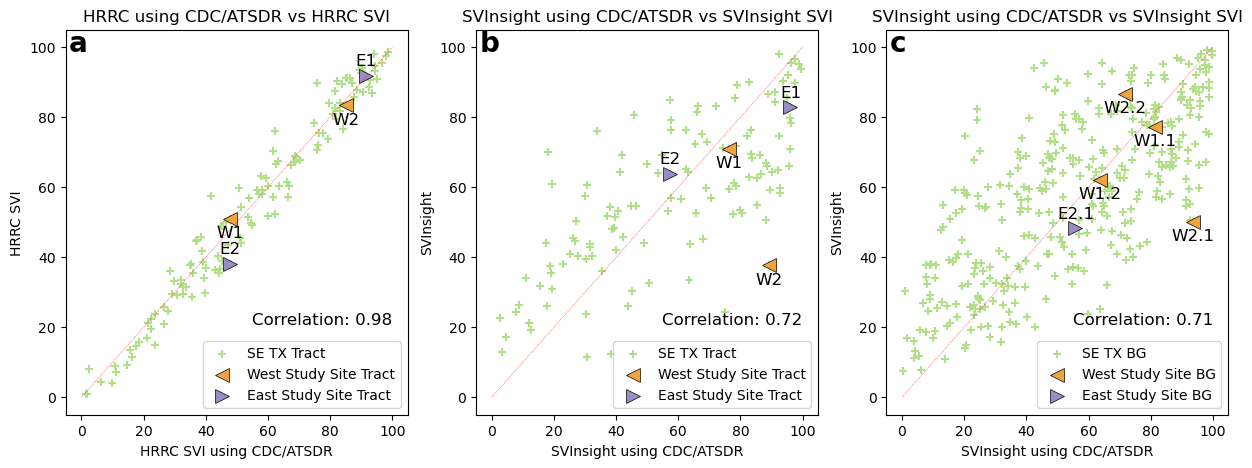

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

svi_tract_dict = select_svi_vars_v2(HRRC_df, airsite_var='airsite_tract')

label1 = 'HRRC SVI using CDC/ATSDR'
label2 = 'HRRC SVI'

axes_plot(0, axes=axes, 
            df_dict = svi_tract_dict, 
            svi1='HRRC_pr_sumpr', svi2='H202090012', 
            label1=label1, label2=label2, 
            title='HRRC using CDC/ATSDR vs HRRC SVI', 
            legend1='SE TX Tract',
            legend2='Study Site Tract')

svi_tract_dict = select_svi_vars_v2(UT_df, airsite_var='airsite_tract')

label1 = 'SVInsight using CDC/ATSDR'
label2 = 'SVInsight'

axes_plot(1, axes=axes, 
            df_dict = svi_tract_dict, 
            svi1='UT_pr_sumpr', svi2='U202090012', 
            label1=label1, label2=label2, 
            title='SVInsight using CDC/ATSDR vs SVInsight SVI', 
            legend1='SE TX Tract',
            legend2='Study Site Tract')

svi_BG_dict = select_svi_vars_v2(UT_BG_df, airsite_var='airsite_bg')

label1 = 'SVInsight using CDC/ATSDR'
label2 = 'SVInsight'

axes_plot(2, axes=axes, 
            df_dict = svi_BG_dict, 
            svi1='UT_pr_sumpr', svi2='U202090012', 
            label1=label1, label2=label2, 
            title='SVInsight using CDC/ATSDR vs SVInsight SVI', 
            legend1='SE TX BG',
            legend2='Study Site BG')

# save figure
#outputfile = os.path.join(programname, f'{programname}_figure3.jpeg')
#plt.savefig(outputfile, dpi=600, bbox_inches='tight')

<Axes: title={'center': 'SVInsight using CDC/ATSDR vs HRRC SVI using CDC/ATSDR'}, xlabel='SVInsight using CDC/ATSDR', ylabel='HRRC SVI using CDC/ATSDR'>

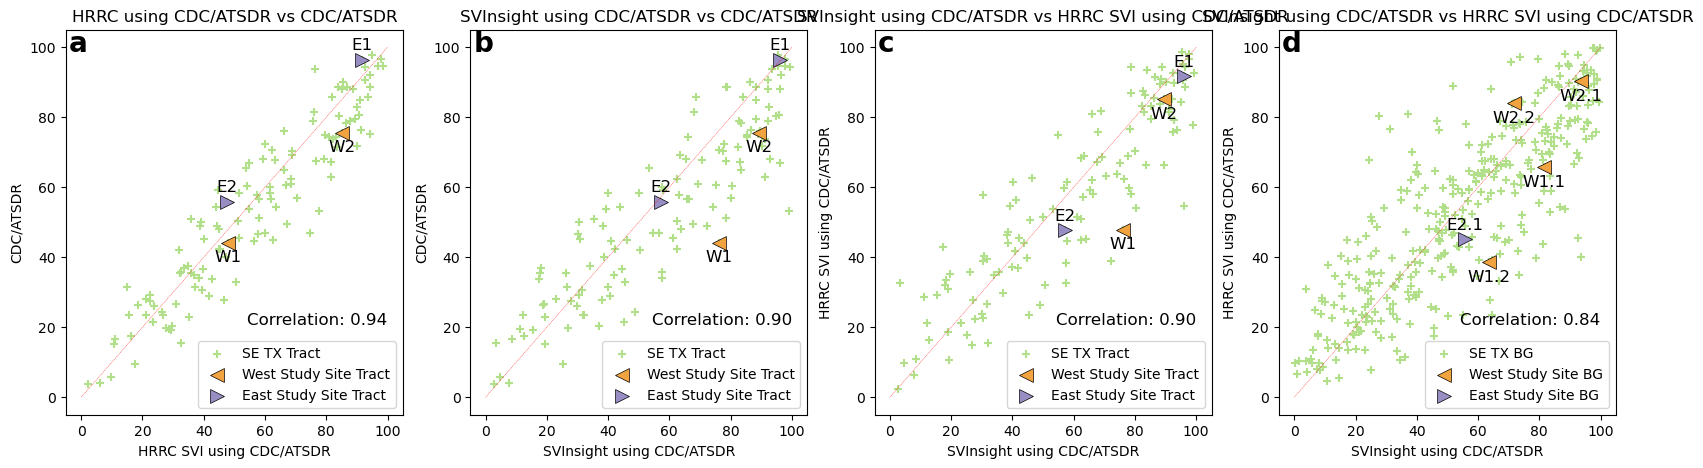

In [130]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

svi_tract_dict = select_svi_vars_v2(HRRC_df, airsite_var='airsite_tract')

label1 = 'HRRC SVI using CDC/ATSDR'
label2 = 'CDC/ATSDR'

axes_plot(0, axes=axes, 
            df_dict = svi_tract_dict, 
            svi1='HRRC_pr_sumpr', svi2='C202090012', 
            label1=label1, label2=label2, 
            title='HRRC using CDC/ATSDR vs CDC/ATSDR', 
            legend1='SE TX Tract',
            legend2='Study Site Tract')

svi_tract_dict = select_svi_vars_v2(UT_df, airsite_var='airsite_tract')

label1 = 'SVInsight using CDC/ATSDR'
label2 = 'CDC/ATSDR'

axes_plot(1, axes=axes, 
            df_dict = svi_tract_dict, 
            svi1='UT_pr_sumpr', svi2='C202090012', 
            label1=label1, label2=label2, 
            title='SVInsight using CDC/ATSDR vs CDC/ATSDR', 
            legend1='SE TX Tract',
            legend2='Study Site Tract')

# merge HRRC_df and UT_df on TRACT2020 to create a combined dataframe
combined_df = HRRC_df[['TRACT2020', 'HRRC_pr_sumpr','SETX','airsite_tract','airsite_name']].merge(
    UT_df[['TRACT2020', 'UT_pr_sumpr']], on='TRACT2020')

svi_tract_dict = select_svi_vars_v2(combined_df, airsite_var='airsite_tract')

label1 = 'SVInsight using CDC/ATSDR'
label2 = 'HRRC SVI using CDC/ATSDR'

axes_plot(2, axes=axes, 
            df_dict = svi_tract_dict, 
            svi1='UT_pr_sumpr', svi2='HRRC_pr_sumpr', 
            label1=label1, label2=label2, 
            title='SVInsight using CDC/ATSDR vs HRRC SVI using CDC/ATSDR', 
            legend1='SE TX Tract',
            legend2='Study Site Tract')

# merge HRRC_df and UT_df on TRACT2020 to create a combined dataframe
combined_BG_df = HRRC_BG_df[['BG2020', 'HRRC_pr_sumpr','SETX','airsite_bg','airsite_name']].merge(
    UT_BG_df[['BG2020', 'UT_pr_sumpr']], on='BG2020')

svi_bg_dict = select_svi_vars_v2(combined_BG_df, airsite_var='airsite_bg')

label1 = 'SVInsight using CDC/ATSDR'
label2 = 'HRRC SVI using CDC/ATSDR'

axes_plot(3, axes=axes, 
            df_dict = svi_bg_dict, 
            svi1='UT_pr_sumpr', svi2='HRRC_pr_sumpr', 
            label1=label1, label2=label2, 
            title='SVInsight using CDC/ATSDR vs HRRC SVI using CDC/ATSDR', 
            legend1='SE TX BG',
            legend2='Study Site BG')

# save figure
#outputfile = os.path.join(programname, f'{programname}_figure3.jpeg')
#plt.savefig(outputfile, dpi=600, bbox_inches='tight')

In [101]:
# merge HRRC_df and UT_df on TRACT2020 to create a combined dataframe
combined_df = HRRC_df[['TRACT2020', 'HRRC_pr_sumpr','H202090012','SETX','airsite_tract','airsite_name']].merge(
    UT_df[['TRACT2020', 'UT_pr_sumpr','U202090012']], on='TRACT2020')

# select from combined_df if airsite_tract 1
condition = combined_df['airsite_tract'] == 1
combined_df_sites = combined_df[condition].copy(deep=True)
combined_df_sites.head()

,TRACT2020,HRRC_pr_sumpr,H202090012,SETX,airsite_tract,airsite_name,UT_pr_sumpr,U202090012
1368,48245005900,85.17,83.5,1.0,1.0,W2,89.36,37.670
1424,48245006600,91.65,91.9,1.0,1.0,E1,96.11,82.799
2258,48245010600,47.71,38.2,1.0,1.0,E2,57.28,63.912
3819,48245005100,47.83,51.0,1.0,1.0,W1,76.18,71.062


In [105]:
(85.17	+47.83)/2

66.5

In [ ]:
(91.65+47.71)/2

82.77000000000001

In [103]:
(96.11+57.28)/2

76.695

In [107]:
(89.36+76.18)/2

82.77000000000001

In [131]:
# merge HRRC_df and UT_df on BG2020 to create a combined dataframe
combined_BG_df = HRRC_BG_df[['BG2020', 'HRRC_pr_sumpr','H202090012','SETX','airsite_bg','airsite_name']].merge(
    UT_BG_df[['BG2020', 'UT_pr_sumpr','U202090012']], on='BG2020')

# select from combined_df if airsite_tract 1
condition = combined_BG_df['airsite_bg'] == 1
combined_BG_df_sites = combined_BG_df[condition].copy(deep=True)
combined_BG_df_sites.head()

,BG2020,HRRC_pr_sumpr,H202090012,SETX,airsite_bg,airsite_name,UT_pr_sumpr,U202090012
7962,482450059002,83.99,89.3,1.0,1.0,W2.2,71.59,86.698
10676,482450051002,38.51,44.5,1.0,1.0,W1.2,63.66,62.124
10702,482450059001,90.30,85.9,1.0,1.0,W2.1,93.47,50.179
13790,482450051001,65.68,69.2,1.0,1.0,W1.1,81.46,77.289
14486,482450106005,45.19,45.5,1.0,1.0,E2.1,55.79,48.360


### Look at Benchmark Comparability
The CDC data provides examples for Texas and US. Will need to read in the original data for the US and Texas and look at the four census tracts.

In [ ]:
# make list of the four census tracts with study sites
condition = Tract_df['airsite_name'].notna()
# make list of TRACT2020 with study sites
study_site_tracts = Tract_df[condition]['TRACT2020'].unique().tolist()
study_site_tracts

In [ ]:
airsite_names  = Tract_df[condition][['TRACT2020','airsite_name']].copy()
airsite_names

In [ ]:
# use list to select tracts in CDC SVI data
condition = cdcsvi_tract_df['FIPS'].isin(study_site_tracts)
cdcsvi_tract_df_tx_airsistes = cdcsvi_tract_df[condition].copy()

condition = cdcsvi_tract_df_US['FIPS'].isin(study_site_tracts)
cdcsvi_tract_df_us_airsistes = cdcsvi_tract_df_US[condition].copy()

In [ ]:
### Keep variables of that start with EPL_
# make list of variables that start with EPL_
EPL_list = cdcsvi_tract_df_tx_airsistes.columns[cdcsvi_tract_df_tx_airsistes.columns.str.startswith('EPL_')].tolist()

cdcsvi_tract_df_tx_airsistes_v2 = cdcsvi_tract_df_tx_airsistes[['FIPS','RPL_THEMES']+EPL_list].copy()
# merge airsite names with SVI data
cdcsvi_tract_df_tx_airsistes_v2 = cdcsvi_tract_df_tx_airsistes_v2.merge(airsite_names, left_on='FIPS', right_on='TRACT2020', how='left')
cdcsvi_tract_df_tx_airsistes_v2 = cdcsvi_tract_df_tx_airsistes_v2.T
# make index a new column
cdcsvi_tract_df_tx_airsistes_v2.reset_index(inplace=True)

# use airsite name as the headings for the columns
cdcsvi_tract_df_tx_airsistes_v2.columns = cdcsvi_tract_df_tx_airsistes_v2.iloc[-1]
# reset index
cdcsvi_tract_df_tx_airsistes_v2 = cdcsvi_tract_df_tx_airsistes_v2[1:]

# rename W1 to W1_US
cdcsvi_tract_df_tx_airsistes_v2.rename(columns = {'W1' : 'W1 TX',
                                                'W2' : 'W2 TX', 
                                                'E1' : 'E1 TX',
                                                'E2' : 'E2 TX',
                                                'airsite_name' : 'indicator'}
                                                    , inplace=True)
cdcsvi_tract_df_tx_airsistes_v2


In [ ]:
cdcsvi_tract_df_us_airsistes_v2 = cdcsvi_tract_df_us_airsistes[['FIPS','RPL_THEMES']+EPL_list].copy()
# merge airsite names with SVI data
cdcsvi_tract_df_us_airsistes_v2 = cdcsvi_tract_df_us_airsistes_v2.merge(airsite_names, left_on='FIPS', right_on='TRACT2020', how='left')
cdcsvi_tract_df_us_airsistes_v2 = cdcsvi_tract_df_us_airsistes_v2.T
# make index a new column
cdcsvi_tract_df_us_airsistes_v2.reset_index(inplace=True)

# use airsite name as the headings for the columns
cdcsvi_tract_df_us_airsistes_v2.columns = cdcsvi_tract_df_us_airsistes_v2.iloc[-1]
# rename W1 to W1_US

cdcsvi_tract_df_us_airsistes_v2.rename(columns = {'W1' : 'W1 US',
                                                'W2' : 'W2 US', 
                                                'E1' : 'E1 US',
                                                'E2' : 'E2 US',
                                                'airsite_name' : 'indicator'}
                                                    , inplace=True)
cdcsvi_tract_df_us_airsistes_v2

In [ ]:
# merge us and texas by indicator
cdcsvi_tract_df_airsistes_v3 = cdcsvi_tract_df_tx_airsistes_v2.merge(cdcsvi_tract_df_us_airsistes_v2, left_on='indicator', right_on='indicator', how='left')
# drop rows for airsite_name
condition = cdcsvi_tract_df_airsistes_v3['indicator'] == 'airsite_name'
cdcsvi_tract_df_airsistes_v3 = cdcsvi_tract_df_airsistes_v3[~condition]
condition = cdcsvi_tract_df_airsistes_v3['indicator'] == 'TRACT2020'
cdcsvi_tract_df_airsistes_v3 = cdcsvi_tract_df_airsistes_v3[~condition]
# convert all columns to float
cdcsvi_tract_df_airsistes_v3['W1 TX'] =  cdcsvi_tract_df_airsistes_v3['W1 TX'].astype(float)
cdcsvi_tract_df_airsistes_v3['W1 US'] =  cdcsvi_tract_df_airsistes_v3['W1 US'].astype(float)
cdcsvi_tract_df_airsistes_v3['W2 TX'] =  cdcsvi_tract_df_airsistes_v3['W2 TX'].astype(float)
cdcsvi_tract_df_airsistes_v3['W2 US'] =  cdcsvi_tract_df_airsistes_v3['W2 US'].astype(float)
cdcsvi_tract_df_airsistes_v3['E1 TX'] =  cdcsvi_tract_df_airsistes_v3['E1 TX'].astype(float)
cdcsvi_tract_df_airsistes_v3['E1 US'] =  cdcsvi_tract_df_airsistes_v3['E1 US'].astype(float)
cdcsvi_tract_df_airsistes_v3['E2 TX'] =  cdcsvi_tract_df_airsistes_v3['E2 TX'].astype(float)
cdcsvi_tract_df_airsistes_v3['E2 US'] =  cdcsvi_tract_df_airsistes_v3['E2 US'].astype(float)

cdcsvi_tract_df_airsistes_v3

In [ ]:
# calculate difference between US and TX values
# loop over airsite names
for airsite in ['W1', 'W2', 'E1', 'E2']:
    cdcsvi_tract_df_airsistes_v3[airsite+" diff"] = cdcsvi_tract_df_airsistes_v3[airsite + " TX"] - cdcsvi_tract_df_airsistes_v3[airsite + " US"]

In [ ]:
# resort columns 
resort_col = ['indicator', 'W1 TX', 'W1 US', 'W1 diff',
                'W2 TX', 'W2 US', 'W2 diff',
                'E1 TX', 'E1 US',  'E1 diff',
                'E2 TX', 'E2 US', 'E2 diff']
cdcsvi_tract_df_airsistes_v3 = cdcsvi_tract_df_airsistes_v3[resort_col]

In [ ]:
cdcsvi_tract_df_airsistes_v3

In [ ]:
# save as csv
cdcsvi_tract_df_airsistes_v3.to_csv(programname+"/"+programname+"_benchmark.csv", index=False)


In [ ]:
def compare_TX_US(df_tx, df_us, variable):
    # Replace -999 with NaN for better handling of missing values
    df_tx[variable] = df_tx[variable].replace(-999, np.nan)
    df_us[variable] = df_us[variable].replace(-999, np.nan)

    # Calculate statistics for Texas
    tx_mean = df_tx[variable].mean()
    tx_median = df_tx[variable].median()
    tx_q25 = df_tx[variable].quantile(0.25)
    tx_q75 = df_tx[variable].quantile(0.75)

    # Calculate statistics for US
    us_mean = df_us[variable].mean()
    us_median = df_us[variable].median()
    us_q25 = df_us[variable].quantile(0.25)
    us_q75 = df_us[variable].quantile(0.75)

    # Plot histograms
    plt.figure(figsize=(12, 6))

    # Histogram for Texas with density
    plt.hist(df_tx[variable].dropna(), bins=50, alpha=0.5, density=True, label='Texas')

    # Histogram for US with density
    plt.hist(df_us[variable].dropna(), bins=50, alpha=0.5, density=True, label='US')

    # Add vertical lines for statistics
    plt.axvline(tx_mean, color='blue', linestyle='--', label='Texas Mean')
    plt.axvline(tx_median, color='blue', linestyle='-', label='Texas Median')
    plt.axvline(tx_q25, color='blue', linestyle=':', label='Texas 25th Percentile')
    plt.axvline(tx_q75, color='blue', linestyle='-.', label='Texas 75th Percentile')

    plt.axvline(us_mean, color='orange', linestyle='--', label='US Mean')
    plt.axvline(us_median, color='orange', linestyle='-', label='US Median')
    plt.axvline(us_q25, color='orange', linestyle=':', label='US 25th Percentile')
    plt.axvline(us_q75, color='orange', linestyle='-.', label='US 75th Percentile')

    # Add labels and legend
    plt.xlabel(variable)
    plt.ylabel('Density')
    plt.title(f'Histogram of {variable} for Texas and US')
    plt.legend()
    plt.show()

In [ ]:

compare_TX_US(cdcsvi_tract_df,cdcsvi_tract_df_US,'EPL_LIMENG')

In [ ]:
compare_TX_US(cdcsvi_tract_df,cdcsvi_tract_df_US,'EP_UNINSUR')

In [ ]:
compare_TX_US(cdcsvi_tract_df,cdcsvi_tract_df_US,'EPL_NOHSDP')

In [ ]:
compare_TX_US(cdcsvi_tract_df,cdcsvi_tract_df_US,'EPL_MINRTY')

In [ ]:
compare_TX_US(cdcsvi_tract_df,cdcsvi_tract_df_US,'EPL_NOVEH')

In [ ]:
compare_TX_US(cdcsvi_tract_df,cdcsvi_tract_df_US,'EPL_NOVEH')

# Explore Results

### Create table 1 with variable values for each tract and block group in study sites

In [ ]:
# for table 1 keep only year = 2020
condition = table1_df['year'] == 2020
table1_df_v2 = table1_df[condition]
# keep columns with new varname
keep_cols = ['Common Category', 'newvarname CDC', 'newvarname HRRC', 'newvarname SVInsight']
table1_df_v2 = table1_df_v2[keep_cols]
# rename columns
table1_df_v2.rename(columns={'newvarname CDC': 'CDC',
                            'newvarname HRRC': 'HRRC',
                            'newvarname SVInsight': 'SVInsight'}, inplace=True)
# fill missing values with empty string
table1_df_v2.fillna('', inplace=True)
# drop first two rows - do not need TRACT and BG ids
condition = table1_df_v2['Common Category'] == 'TRACT2020'
table1_df_v2 = table1_df_v2[~condition]
condition = table1_df_v2['Common Category'] == 'BG2020'
table1_df_v2 = table1_df_v2[~condition]
table1_df_v2 = table1_df_v2.reset_index(drop=True)
table1_df_v2

In [ ]:
# show count of observations by airsite_name
Tract_df_v2['airsite_name'].value_counts()

In [ ]:
airsite_names = {}
airsite_names['Tract_df'] = Tract_df_v2['airsite_name'].unique().tolist()
airsite_names['Tract_df'] = [x for x in airsite_names['Tract_df'] if str(x) != 'nan']
airsite_names['BG_df'] = BG_df['airsite_name'].unique().tolist()
airsite_names['BG_df'] = [x for x in airsite_names['BG_df'] if str(x) != 'nan']
airsite_names['BG_df'] = sorted(airsite_names['BG_df'])
airsite_names['Tract_df'] = sorted(airsite_names['Tract_df'])
airsite_names['Tract_df']

In [ ]:
# select if airsite_name is in airsite_names
# for tract
condition = Tract_df['airsite_name'].isin(airsite_names['Tract_df'])
Tract_df_v2[['TRACT2020','airsite_name']][condition].head()

In [ ]:
airsite_names['BG_df']

In [ ]:
Tract_df_v2.head()

In [ ]:
# loop over table 1 and replace value in cells with value for column in Tract_df
table1_df_v3 = table1_df_v2.copy(deep=True)

dfs = {}
dfs['Tract_df'] = Tract_df_v2.copy(deep=True)
dfs['BG_df'] = BG_df_v2.copy(deep=True)
# loop over dataframes
for key in dfs.keys():
    # loop over airsite names
    for airsite_name in airsite_names[key]:
        #print(airsite_name)
        # select row from Tract_df where airsite_name is first in list
        condition = dfs[key]['airsite_name'] == airsite_name
        select_df = dfs[key][condition]
        # loop over SVI options
        for option in ['CDC','HRRC','SVInsight']:
            # create new column in table 2
            new_colname = option+" "+airsite_name
            new_colname_prank = option+" "+airsite_name+ " percentile rank"
            new_colname_mm = option+" "+airsite_name+ " min-max scaling"
            new_colname_SETXrank = option+" "+airsite_name+ " SETX rank"
            table1_df_v3[new_colname] = ''
            table1_df_v3[new_colname_prank] = ''
            table1_df_v3[new_colname_mm] = ''
            table1_df_v3[new_colname_SETXrank] = ''
            # loop over rows in table 1
            for i in range(len(table1_df_v2)):
                # get the column name from table 1
                colname = table1_df_v2.iloc[i][option]

                if colname != '':
                    #print(colname)

                    # find value in column from Tract_df_airsite
                    try:
                        # get the value for the column name
                        value = select_df.iloc[0][colname]
                        # convert value into formatted string
                        # if value is less than or equal to 1, format as float with 3 decimal places
                        if value <= 1:
                            value = f"{value:,.3f}"
                        # if value is greater than 1, format as float with 0 decimal places
                        elif value > 1:
                            value = f"{value:,.0f}"
                        else:
                            value = str(value)
                        #print("Value: ", value)
                        # replace the value in the column with the value from table 1
                        table1_df_v3.loc[i, new_colname] = value
                    except KeyError:
                        # if the column name is not in Tract_df_airsite, set value to empty string
                        value = 'KeyError'
                        #print("KeyError: ", colname)

                    # add percentile rank to table 1
                    # find value in column from Tract_df_airsite
                    try:
                        # get the value for the column name
                        value = select_df.iloc[0][f'{colname}pr']
                        # convert value into formatted string
                        # if value is less than or equal to 1, format as float with 3 decimal places
                        if value <= 1:
                            value = f"{value:,.3f}"
                        # if value is greater than 1, format as float with 0 decimal places
                        elif value > 1:
                            value = f"{value:,.0f}"
                        else:
                            value = str(value)
                        #print("Value: ", value)
                        # replace the value in the column with the value from table 1
                        table1_df_v3.loc[i, new_colname_prank] = value
                    except KeyError:
                        # if the column name is not in Tract_df_airsite, set value to empty string
                        value = 'KeyError'
                        #print("KeyError: ", colname)

                    # add min-max to table 1
                    # find value in column from Tract_df_airsite
                    try:
                        # get the value for the column name
                        value = select_df.iloc[0][f'{colname}mm']
                        # convert value into formatted string
                        # if value is less than or equal to 1, format as float with 3 decimal places
                        if value <= 1:
                            value = f"{value:,.3f}"
                        # if value is greater than 1, format as float with 0 decimal places
                        elif value > 1:
                            value = f"{value:,.0f}"
                        else:
                            value = str(value)
                        #print("Value: ", value)
                        # replace the value in the column with the value from table 1
                        table1_df_v3.loc[i, new_colname_mm] = value
                    except KeyError:
                        # if the column name is not in Tract_df_airsite, set value to empty string
                        value = 'KeyError'
                        #print("KeyError: ", colname)

                    # add SETX rank
                    # find value in column from Tract_df_airsite
                    try:
                        # get the value for the column name
                        value = select_df.iloc[0][f'{colname}SETXrank']
                        # convert value into formatted string
                        # if value is less than or equal to 1, format as float with 3 decimal places
                        if value <= 1:
                            value = f"{value:,.3f}"
                        # if value is greater than 1, format as float with 0 decimal places
                        elif value > 1:
                            value = f"{value:,.0f}"
                        else:
                            value = str(value)
                        #print("Value: ", value)
                        # replace the value in the column with the value from table 1
                        table1_df_v3.loc[i, new_colname_SETXrank] = value
                    except KeyError:
                        # if the column name is not in Tract_df_airsite, set value to empty string
                        value = 'KeyError'
                        #print("KeyError: ", colname)                     

In [ ]:
table1_df_v3

In [ ]:
# display columns 
columns_to_display1 = ['Common Category', 'CDC', 'HRRC', 'SVInsight']
# display columns that include SETXrank
columns_to_display_2 = [col for col in table1_df_v3.columns if 'SETX rank' in col]
columns_to_display = columns_to_display1 + columns_to_display_2

table1_df_v3[columns_to_display]

### Save output as csv

In [ ]:
# save as csv
table1_df_v3.to_csv(programname+"/"+programname+"_compare.csv", index=False)

In [ ]:
table1_df_v3[columns_to_display].to_csv(programname+"/"+programname+"_SETXrank.csv", index=False)